<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_no_churn"] = df_collection["formated_table"].drop('churn', axis=1)
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["formated_table_with_keys_no_churn"] = get_table_with_keys(df_collection["formated_table_no_churn"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys_no_churn"], n)

df_collection["formated_table_with_keys_no_churn"].head

<bound method NDFrame.head of            key1            credit_score          country       key2  \
0         key_1       Credit_Score_Fair   Country_France      key_1   
1         key_2       Credit_Score_Fair    Country_Spain      key_2   
2         key_3       Credit_Score_Poor   Country_France      key_3   
3         key_4       Credit_Score_Good   Country_France      key_4   
4         key_5  Credit_Score_Excellent    Country_Spain      key_5   
...         ...                     ...              ...        ...   
9995   key_9996  Credit_Score_Very_Good   Country_France   key_9996   
9996   key_9997       Credit_Score_Poor   Country_France   key_9997   
9997   key_9998       Credit_Score_Good   Country_France   key_9998   
9998   key_9999  Credit_Score_Very_Good  Country_Germany   key_9999   
9999  key_10000  Credit_Score_Very_Good   Country_France  key_10000   

             gender                        age       key3     tenure  \
0     Gender_Female  Age_Adults_in_their_Prim

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

seeds = [1, 42, 66]

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())

models = {}  
categories = {} 

# Führe Experimente durch
for seed in seeds:
    base_config = ModelConfig(
        vector_size = 150,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 1e-3,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    runner = ExperimentRunner(trainer, repository, base_config)
    models[seed], categories[seed] = runner.create_many_models(
        sentences=df_collection["n_sentences"]["20"],
        n_sentences_tokenized=df_collection["n_sentences"],
        n_used_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )
    

Model Creation started.
...Creating sentence models...
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_15_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_15_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_75_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_75_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {}

for seed in seeds:
    if seed not in average_sentence_vectors:
        average_sentence_vectors[seed] = {}
    for category in categories[seed]:  
        print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
        
        if category not in average_sentence_vectors[seed]:
            average_sentence_vectors[seed][category] = []
        
        for model in models[seed][category]:
            vectors = create_average_sentence_vectors(
                model, 
                df_collection["formated_table_with_keys"], 
                base_dir=Path.cwd(), 
                verbose=False
            )
            average_sentence_vectors[seed][category].append([vectors, model[1]])
        
        print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")

(-------------Vector calculation of category: SENTENCE-------------)
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] firs

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_sweep_results
    
test_results = get_all_sweep_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

(-------------Test of category: SENTENCE-------------)

(-------------Test of category: VECTOR-------------)

(-------------Test of category: WINDOWSIZE-------------)

(-------------Test of category: EPOCH-------------)

Tests abgeschlossen. 130 Modelle getestet.


<h2>Visualisierung<h2>

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

def render_figure(fig, name, dpi=300, show=True):
    """
    Centralized figure handling:
    - saves in publication-quality formats
    - optionally displays in Jupyter
    - closes figure to avoid memory leaks
    """
    fig.savefig(FIGURE_DIR / f"{name}.pdf")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=dpi)

    if show:
        plt.show()

    plt.close(fig)


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



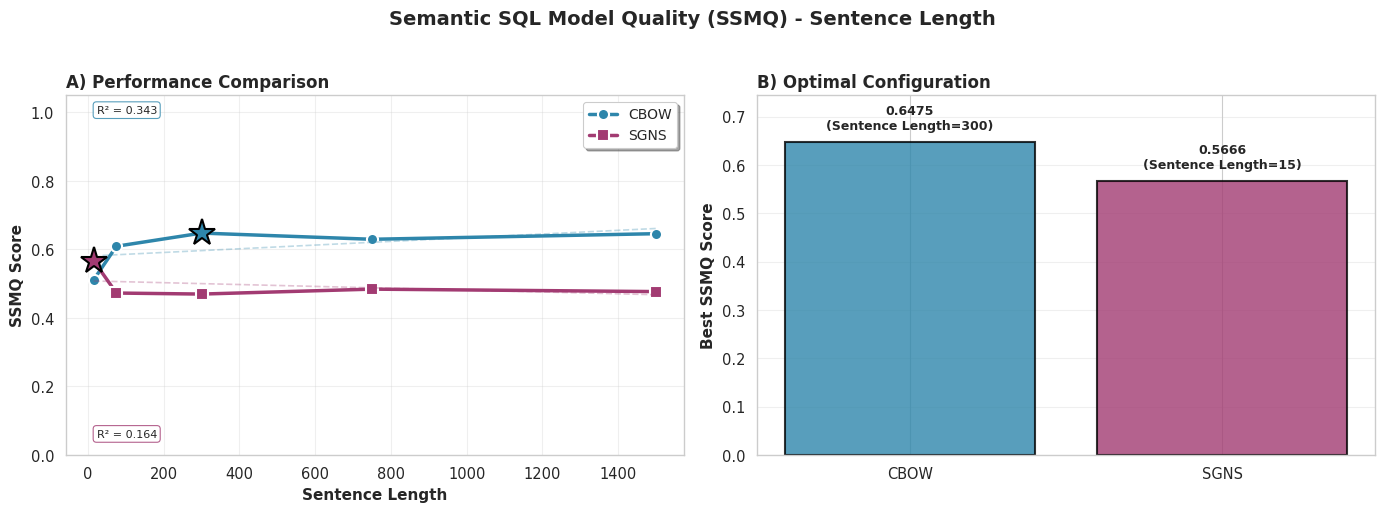

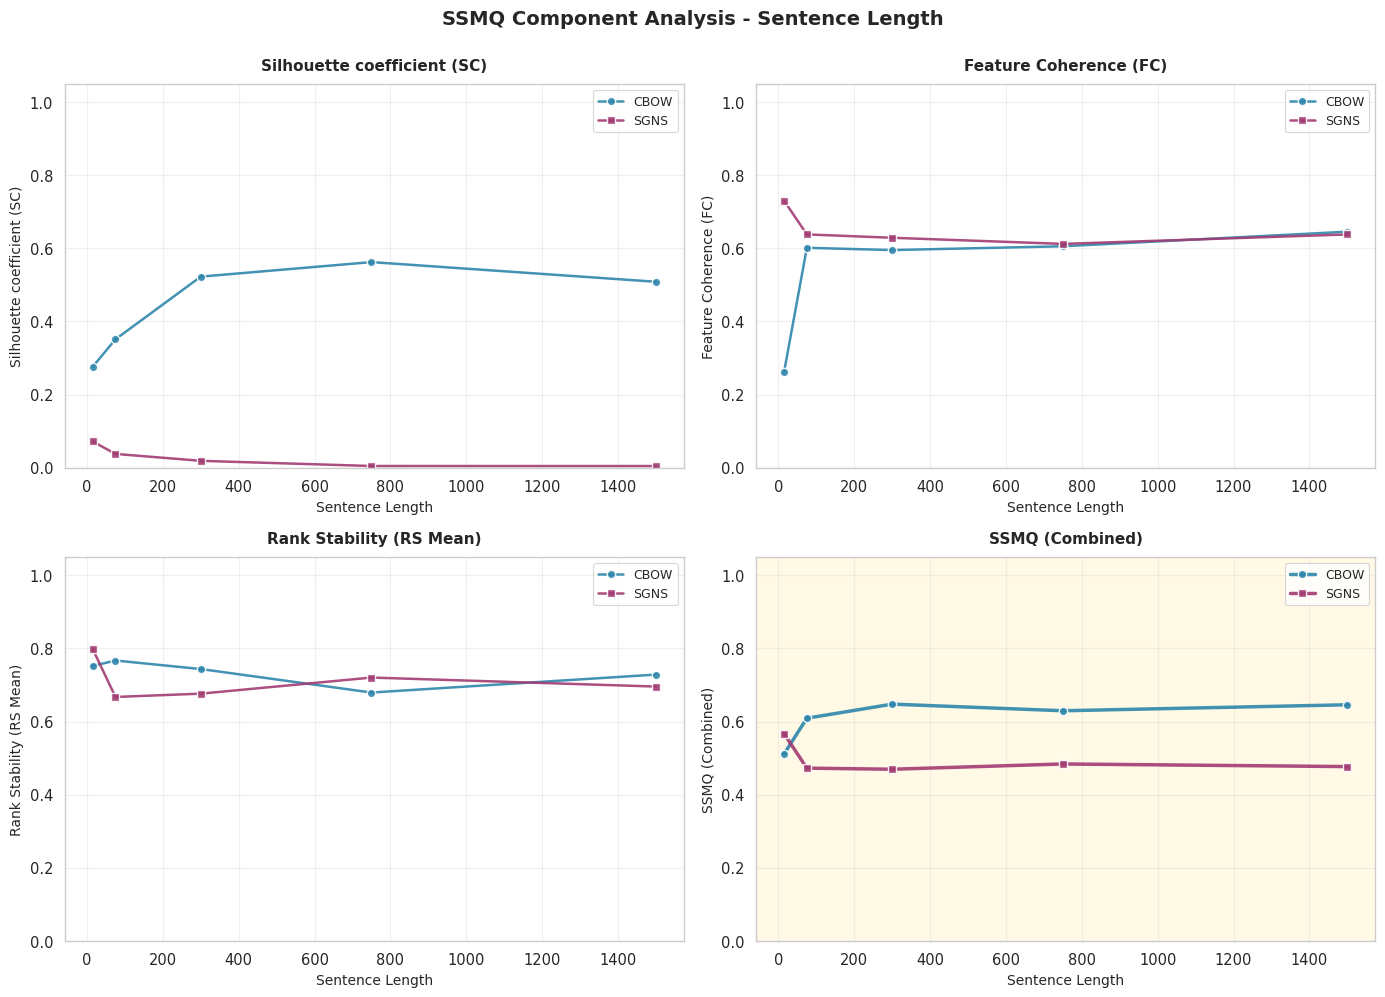


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
15           | 0.2762    0.2621    0.7521    0.5114    | 0.0717    0.7301    0.7980    0.5666   
75           | 0.3512    0.6013    0.7668    0.6090    | 0.0377    0.6380    0.6672    0.4725   
300          | 0.5225    0.5951    0.7435    0.6475    | 0.0188    0.6288    0.6762    0.4695   
750          | 0.5622    0.6055    0.6792    0.6294    | 0.0046    0.6120    0.7202    0.4839   
1500         | 0.5084    0.6454    0.7283    0.6457    | 0.0045    0.6379    0.6956    0.4767   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

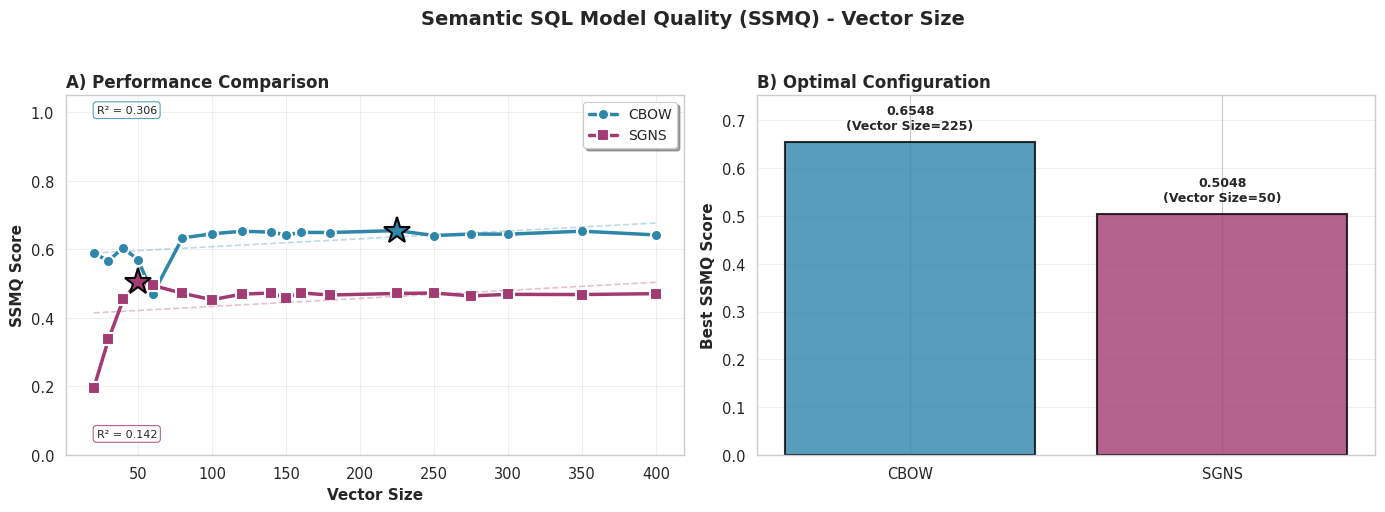

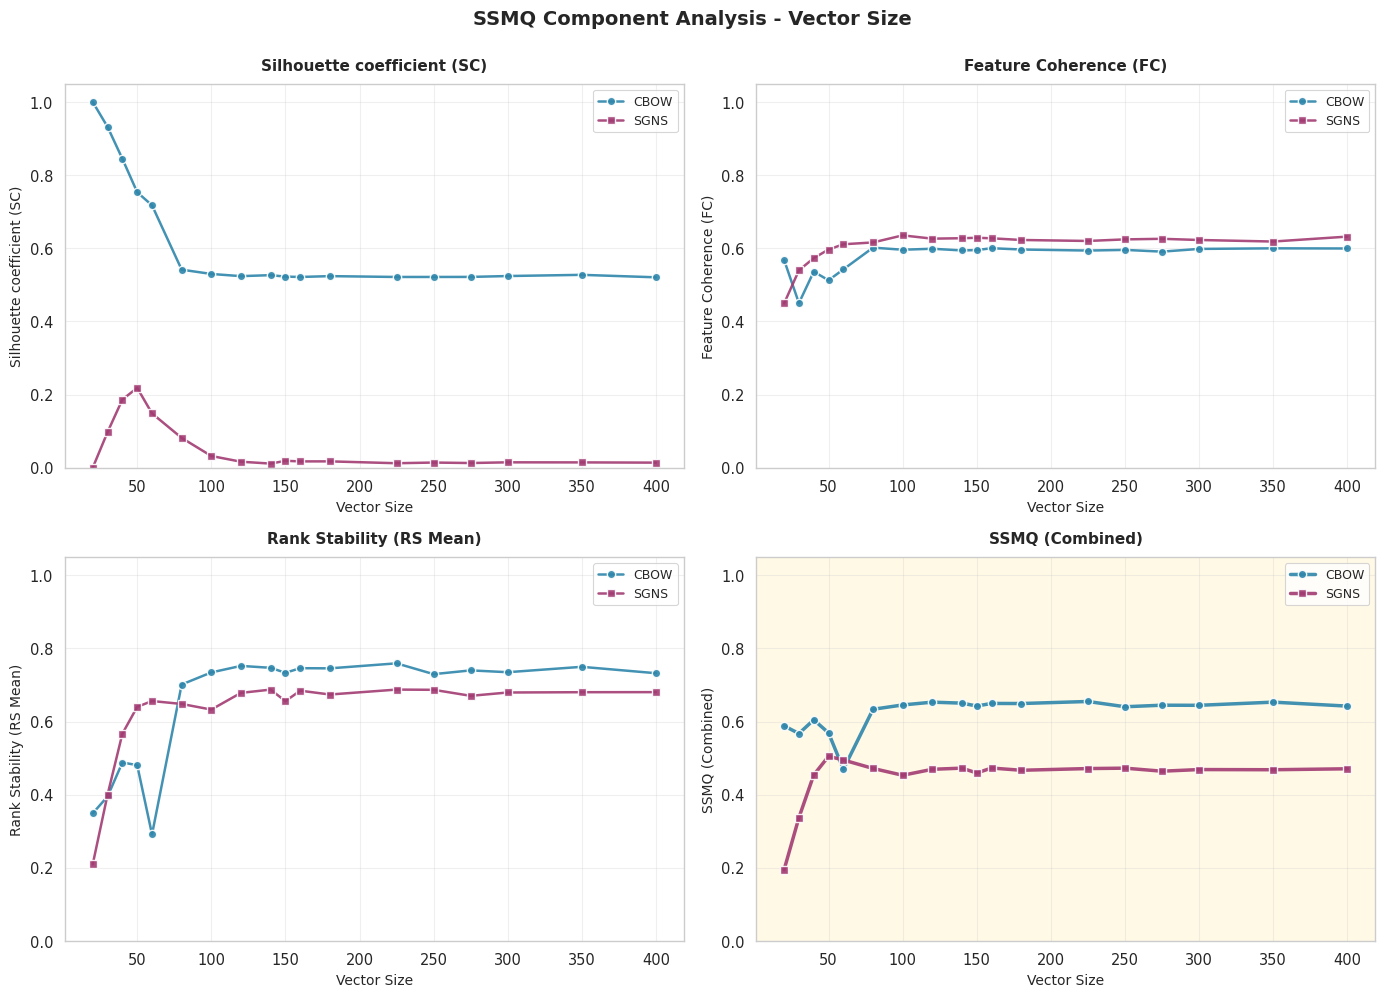


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 1.0000    0.5680    0.3489    0.5880    | 0.0000    0.4492    0.2096    0.1946   
30           | 0.9320    0.4501    0.3950    0.5671    | 0.0974    0.5398    0.3999    0.3371   
40           | 0.8447    0.5361    0.4879    0.6046    | 0.1864    0.5731    0.5667    0.4539   
50           | 0.7533    0.5125    0.4807    0.5688    | 0.2183    0.5966    0.6401    0.5048   
60           | 0.7175    0.5424    0.2913    0.4694    | 0.1484    0.6110    0.6560    0.4947   
80           | 0.5415    0.6018    0.7012    0.6334    | 0.0815    0.6160    0.6480    0.4716   
100          | 0.5298    0.5961    0.7342    0.6453    | 0.0320    0.6353    0.6326   

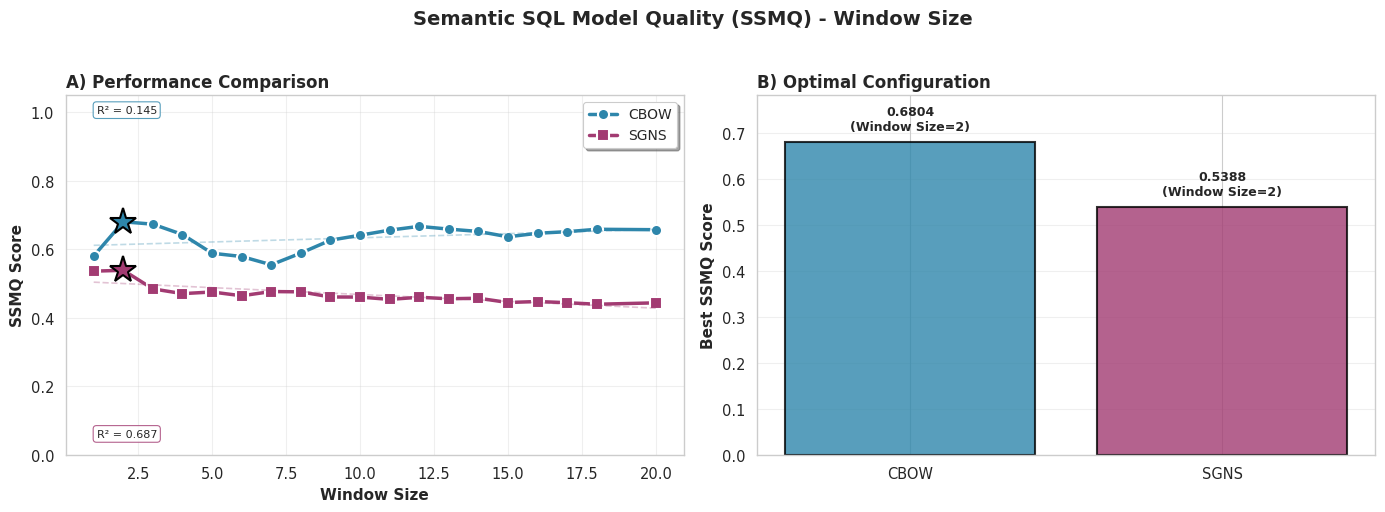

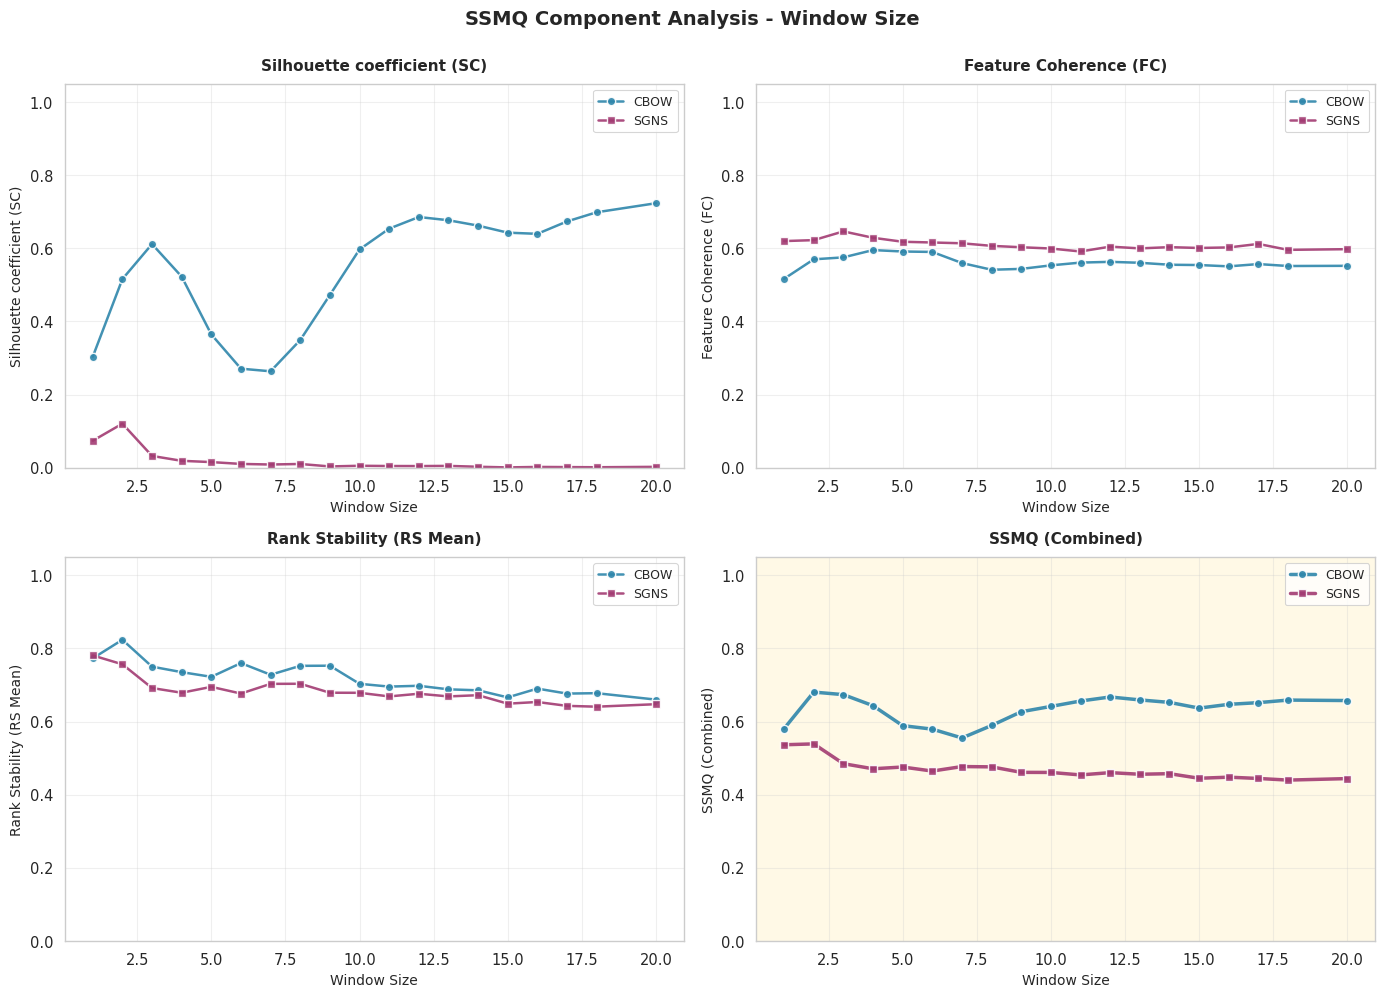


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.3033    0.5165    0.7727    0.5806    | 0.0737    0.6197    0.7807    0.5364   
2            | 0.5157    0.5698    0.8235    0.6804    | 0.1204    0.6223    0.7565    0.5388   
3            | 0.6115    0.5751    0.7500    0.6735    | 0.0321    0.6462    0.6915    0.4847   
4            | 0.5225    0.5951    0.7350    0.6433    | 0.0188    0.6288    0.6787    0.4707   
5            | 0.3645    0.5912    0.7222    0.5887    | 0.0153    0.6178    0.6948    0.4756   
6            | 0.2708    0.5900    0.7598    0.5791    | 0.0103    0.6158    0.6765    0.4645   
7            | 0.2636    0.5597    0.7279    0.5550    | 0.0087    0.6137    0.702

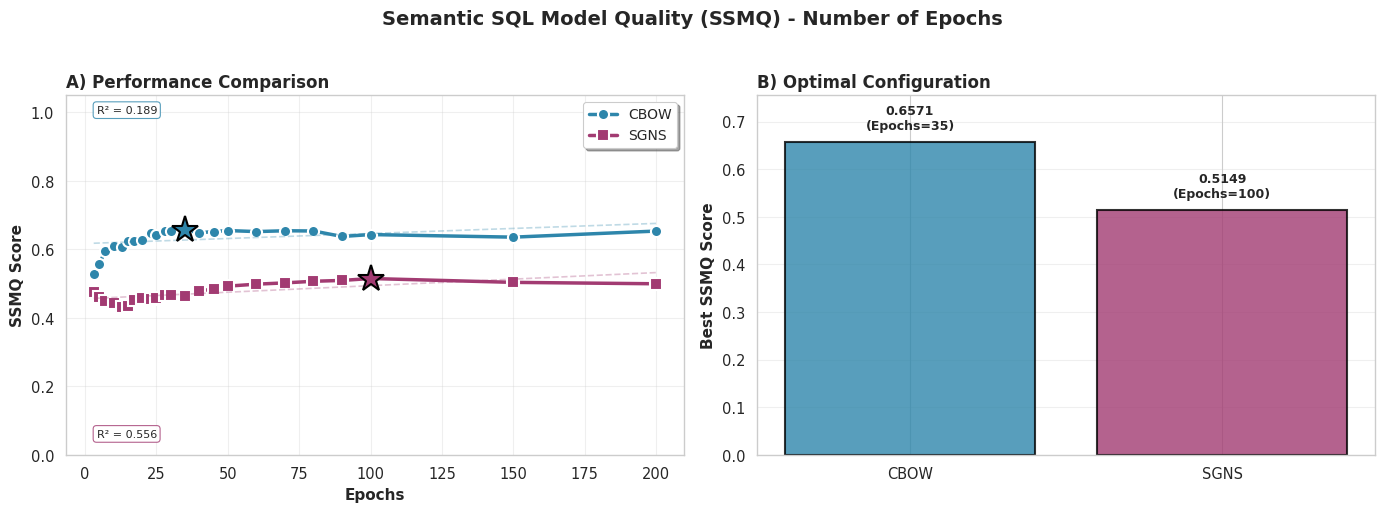

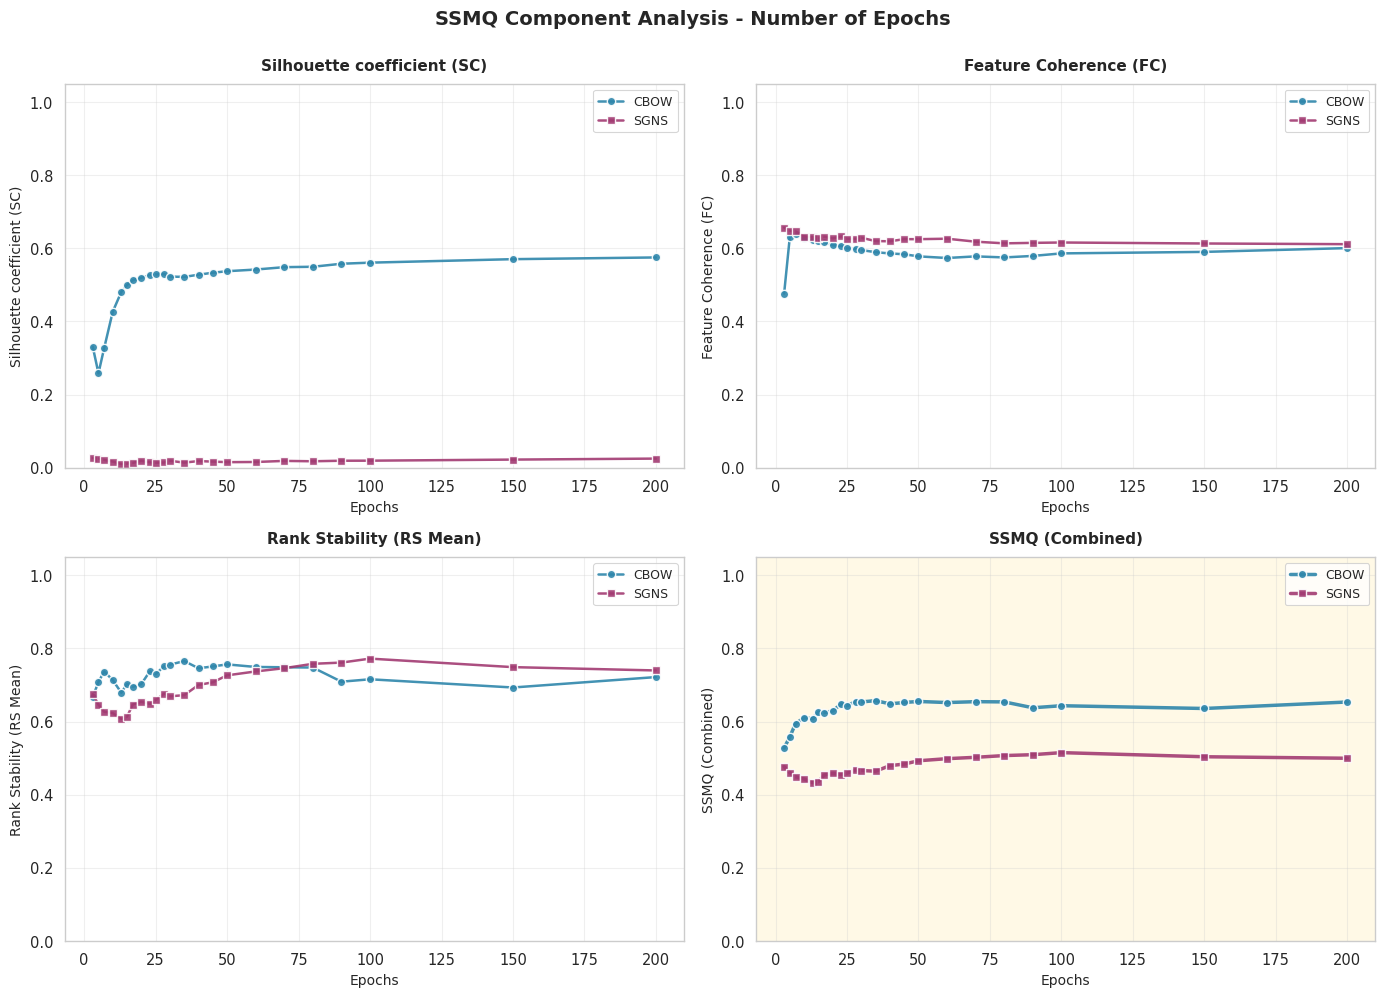


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.3307    0.4760    0.6666    0.5277    | 0.0264    0.6566    0.6747    0.4766   
5            | 0.2584    0.6310    0.7083    0.5579    | 0.0249    0.6481    0.6459    0.4600   
7            | 0.3271    0.6392    0.7367    0.5943    | 0.0211    0.6461    0.6267    0.4489   
10           | 0.4266    0.6276    0.7133    0.6102    | 0.0168    0.6319    0.6229    0.4429   
13           | 0.4809    0.6215    0.6788    0.6079    | 0.0097    0.6301    0.6070    0.4325   
15           | 0.4997    0.6211    0.7030    0.6256    | 0.0111    0.6285    0.6131    0.4356   
17           | 0.5126    0.6168    0.6948    0.6246    | 0.0132    0.6318    0.6465    

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema - UNVERÄNDERT
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends - UNVERÄNDERT (schon richtig)
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        #ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
        #        transform=ax2.transAxes, ha='center', va='top',
        #        fontsize=10, fontweight='bold',
        #        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    return fig
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Silhouette coefficient (SC)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW: Immer professionelles Blau für alle Metriken
            cbow_color = COLORS['CBOW']  # Jetzt immer CBOW-Blau
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS: Immer kontrastierendes Magenta für alle Metriken
            sgns_color = COLORS['SGNS']  # Jetzt immer SGNS-Magenta
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components - Jetzt in hellen Blautönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='#87CEEB', alpha=0.7,  # Heller Blauton für CBOW
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent) - Jetzt in voller CBOW-Farbe
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components - Jetzt in hellen Magentatönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='#FFB6C1', alpha=0.7,  # Heller Magentaton für SGNS
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent) - Jetzt in voller SGNS-Farbe
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'SC':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'SC':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    fig1 = plot_ssmq_main_result(category, category_data, x_label, title_category)
    render_figure(fig1, f"SSMQ_main_{category}")
    
    # FIGURE 2: Komponenten-Analyse
    fig2 = plot_component_analysis(category, category_data, x_label, title_category)
    render_figure(fig2, f"SSMQ_components_{category}")
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)


print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


KEY-VALUE COHERENCE (KVC) ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



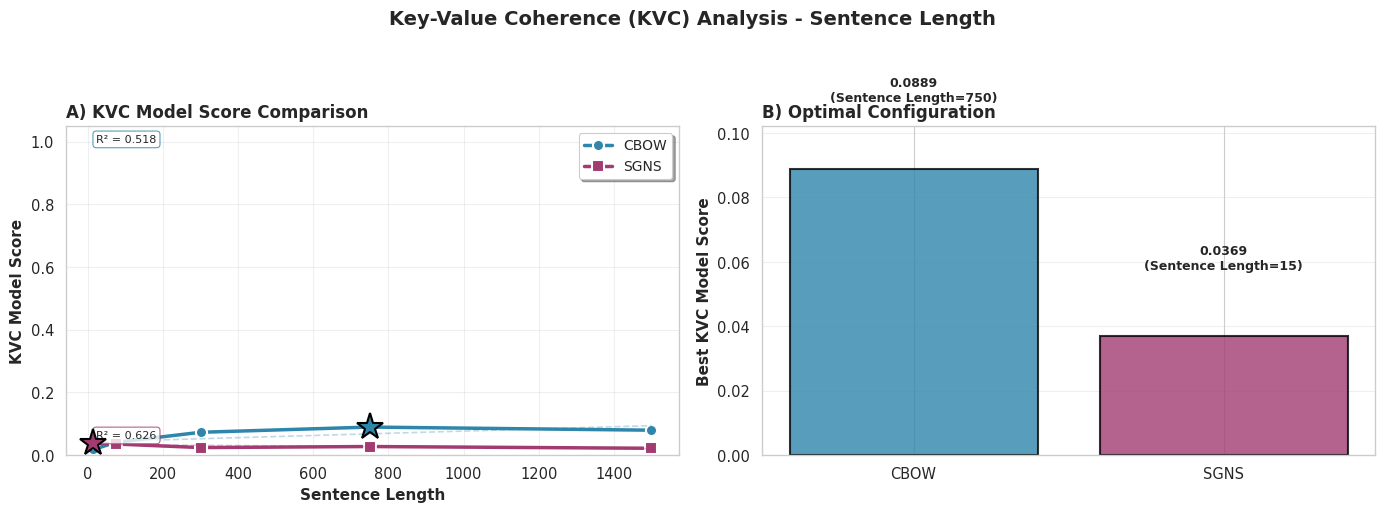

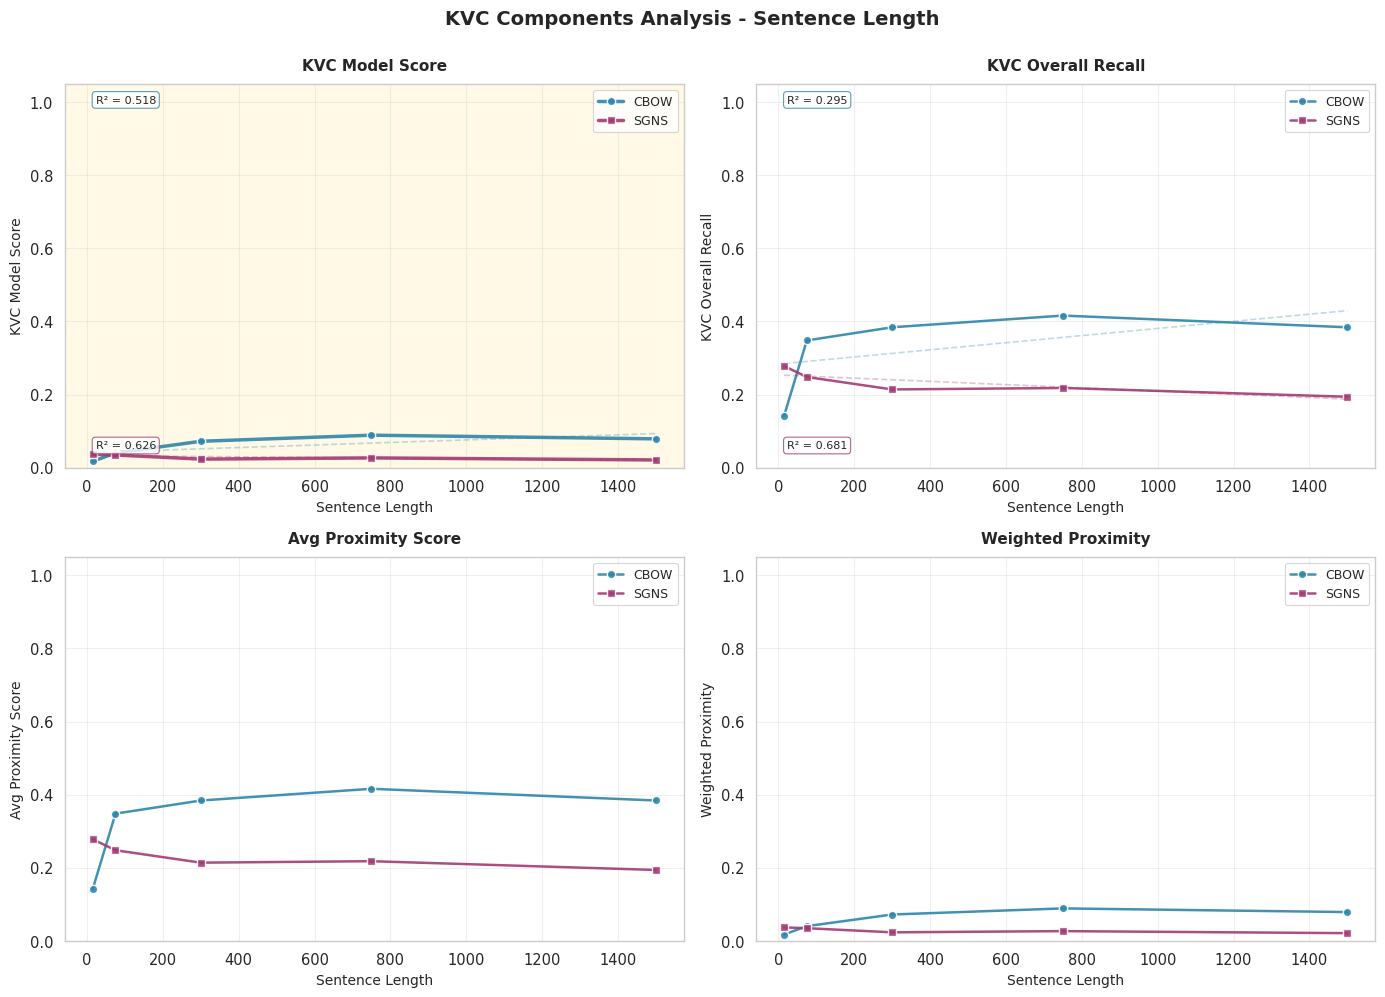

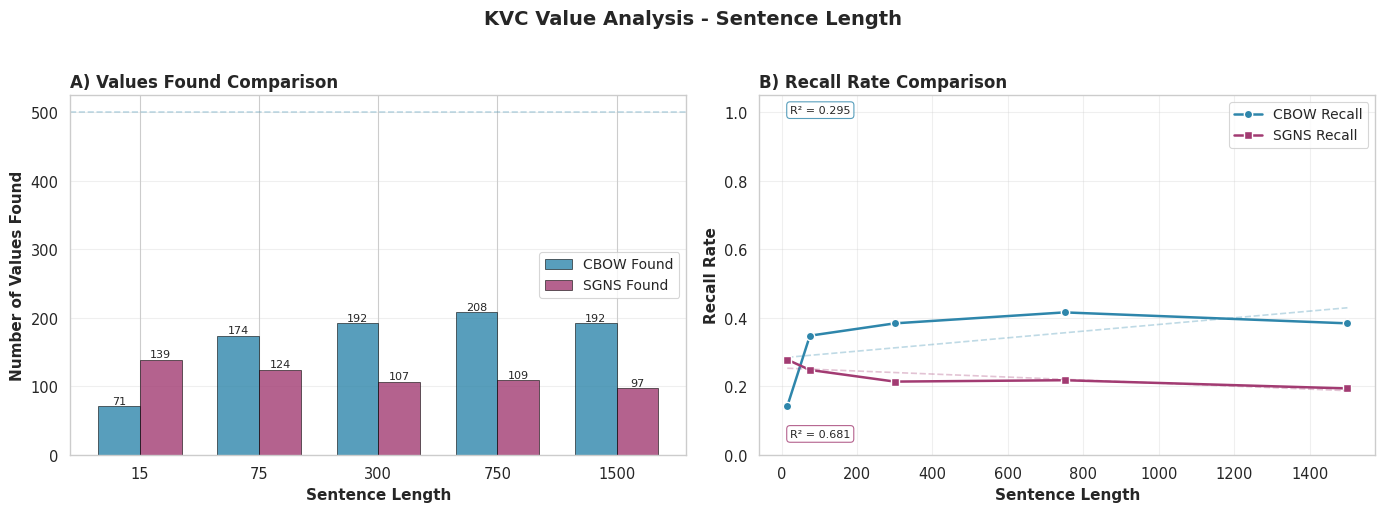


KVC NUMERICAL RESULTS - SENTENCE LENGTH

Sentence Length | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
15           | 0.0174     0.1420     0.1420     0.0174     | 0.0369     0.2780     0.2780     0.0369    
75           | 0.0404     0.3480     0.3480     0.0404     | 0.0348     0.2480     0.2480     0.0348    
300          | 0.0722     0.3840     0.3840     0.0722     | 0.0235     0.2140     0.2140     0.0235    
750          | 0.0889     0.4160     0.4160     0.0889     | 0.0268     0.2180     0.2180     0.0268    
1500         | 0.0789     0.3840     0.3840     0.0789     | 0.0212     0.1940     0.1940     0.0212    

KVC VALUE

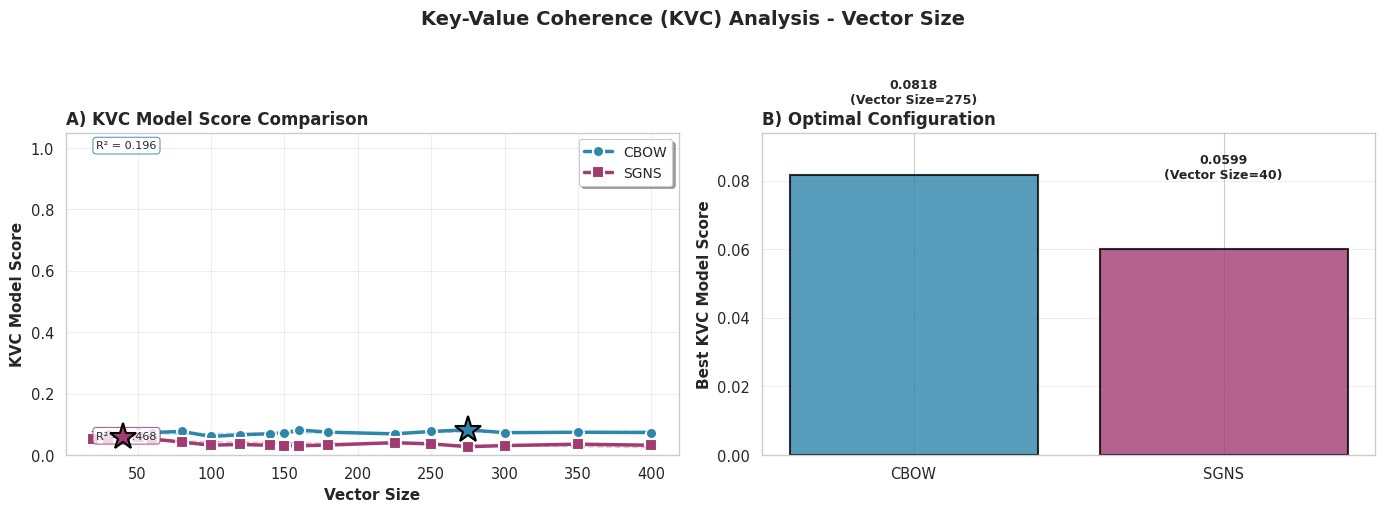

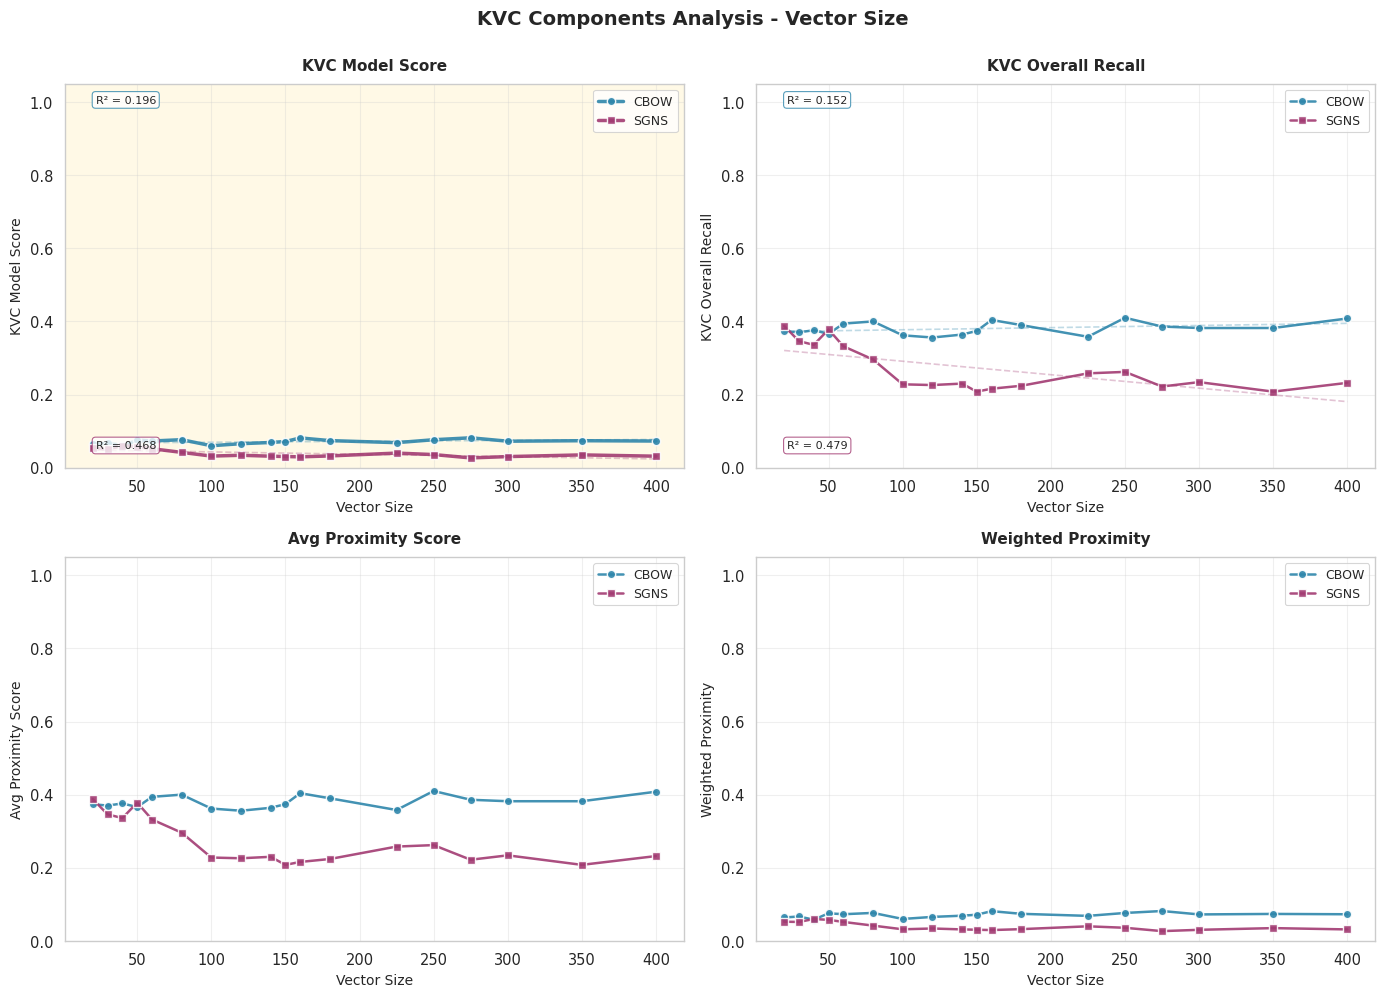

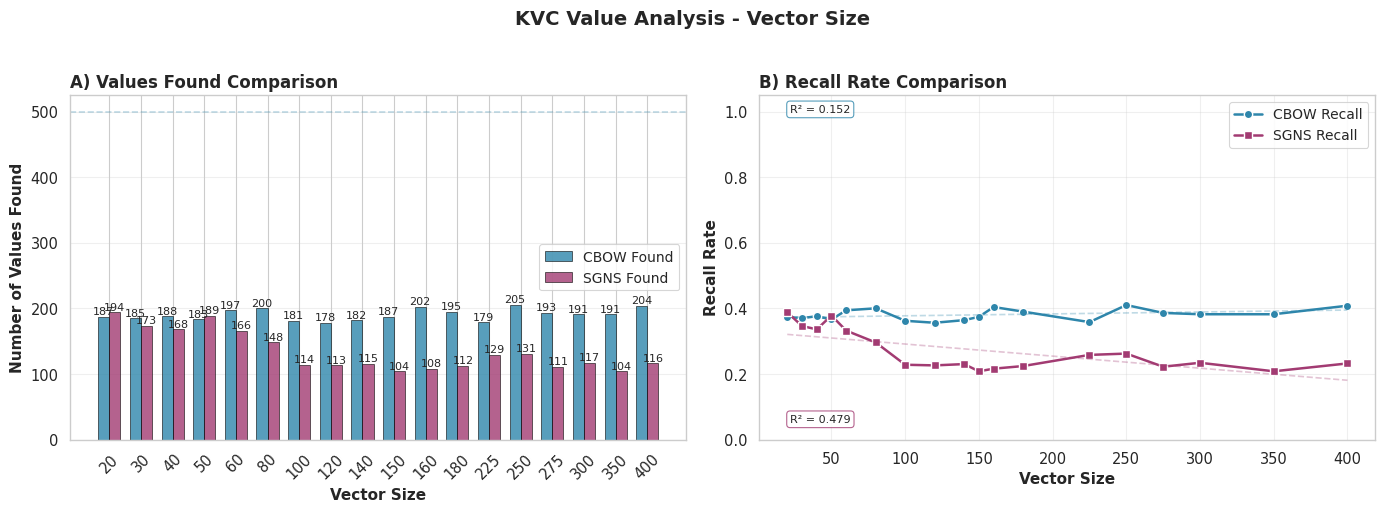


KVC NUMERICAL RESULTS - VECTOR SIZE

Vector Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
20           | 0.0641     0.3740     0.3740     0.0641     | 0.0525     0.3880     0.3880     0.0525    
30           | 0.0668     0.3700     0.3700     0.0668     | 0.0519     0.3460     0.3460     0.0519    
40           | 0.0580     0.3760     0.3760     0.0580     | 0.0599     0.3360     0.3360     0.0599    
50           | 0.0755     0.3660     0.3660     0.0755     | 0.0576     0.3780     0.3780     0.0576    
60           | 0.0730     0.3940     0.3940     0.0730     | 0.0519     0.3320     0.3320     0.0519    
80           | 0.

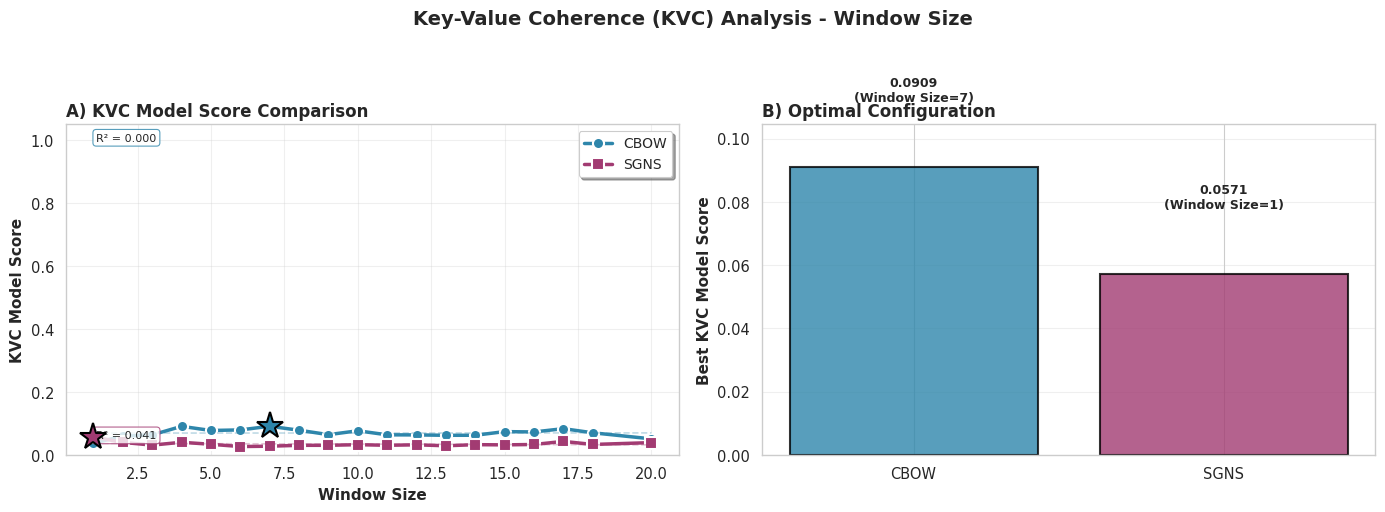

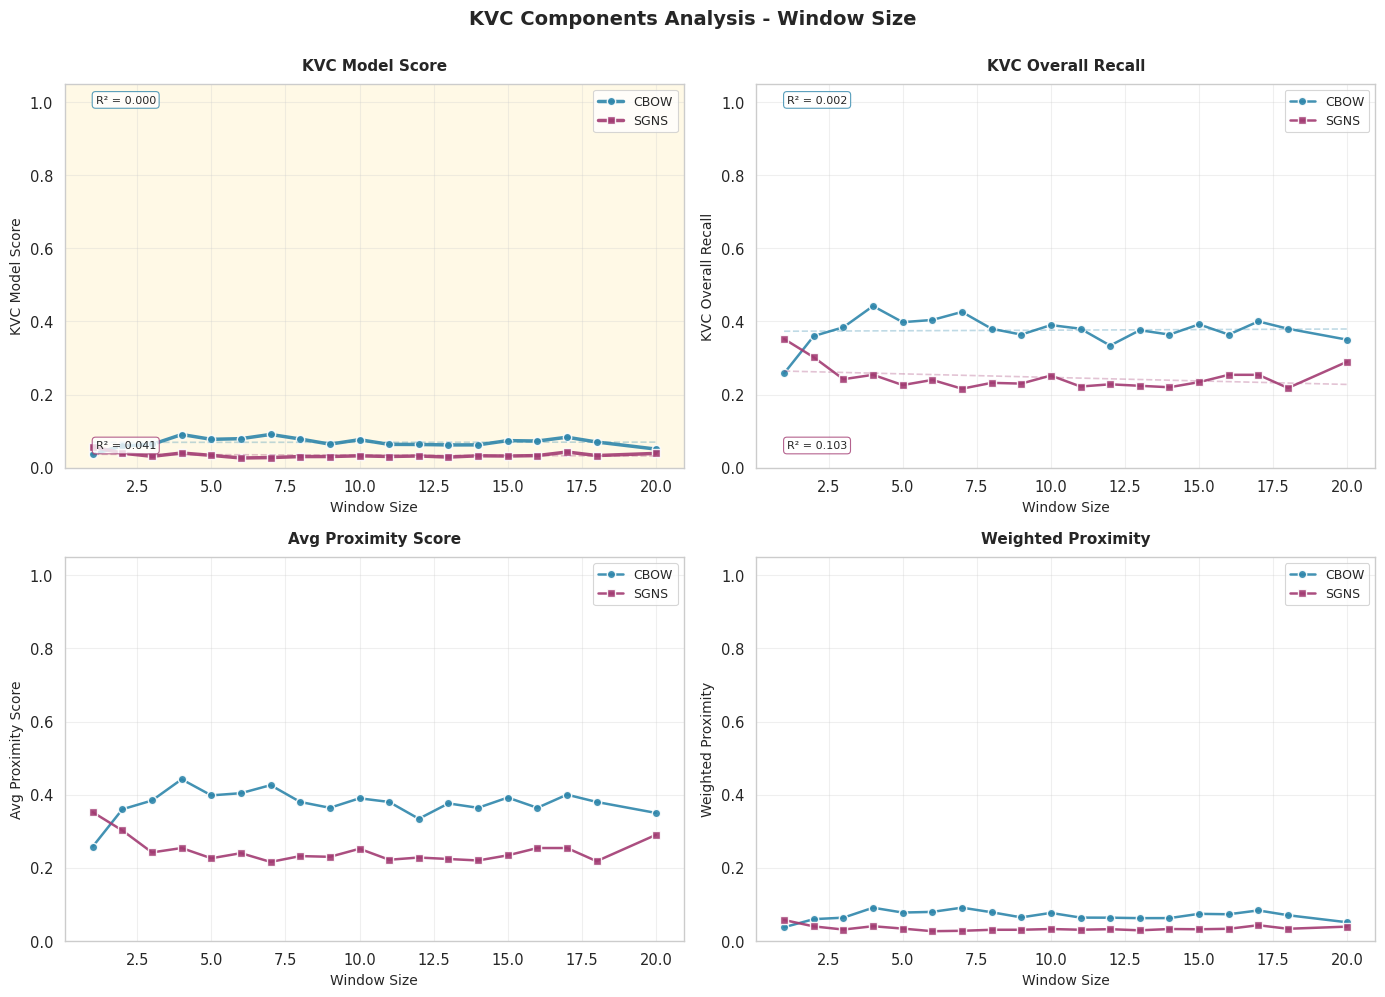

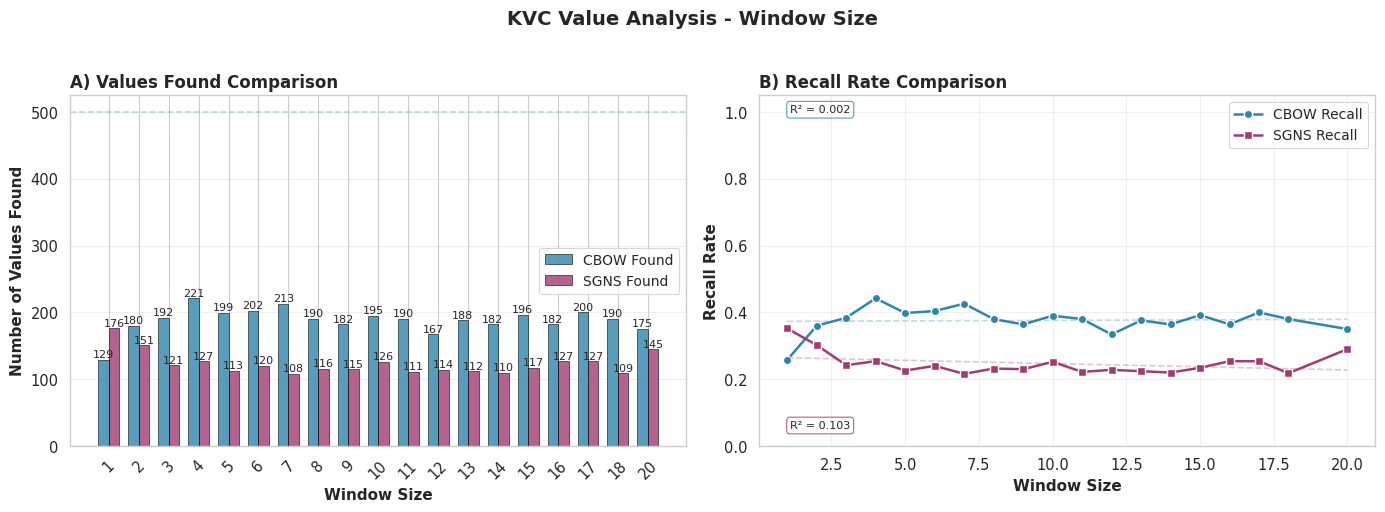


KVC NUMERICAL RESULTS - WINDOW SIZE

Window Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
1            | 0.0374     0.2580     0.2580     0.0374     | 0.0571     0.3520     0.3520     0.0571    
2            | 0.0595     0.3600     0.3600     0.0595     | 0.0397     0.3020     0.3020     0.0397    
3            | 0.0636     0.3840     0.3840     0.0636     | 0.0311     0.2420     0.2420     0.0311    
4            | 0.0908     0.4420     0.4420     0.0908     | 0.0402     0.2540     0.2540     0.0402    
5            | 0.0776     0.3980     0.3980     0.0776     | 0.0337     0.2260     0.2260     0.0337    
6            | 0.

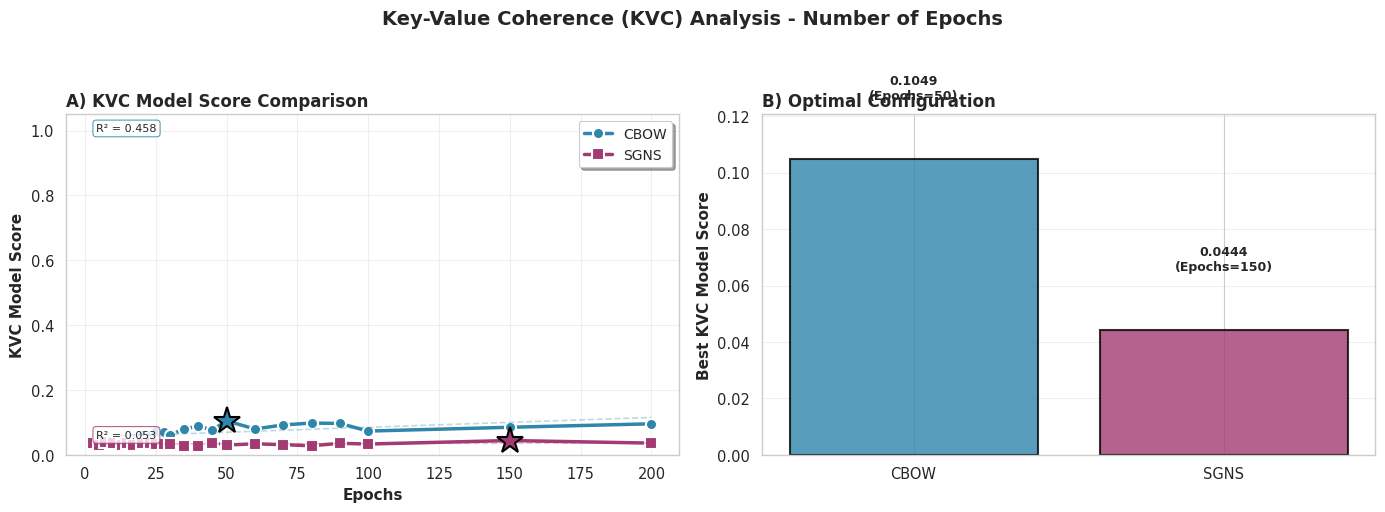

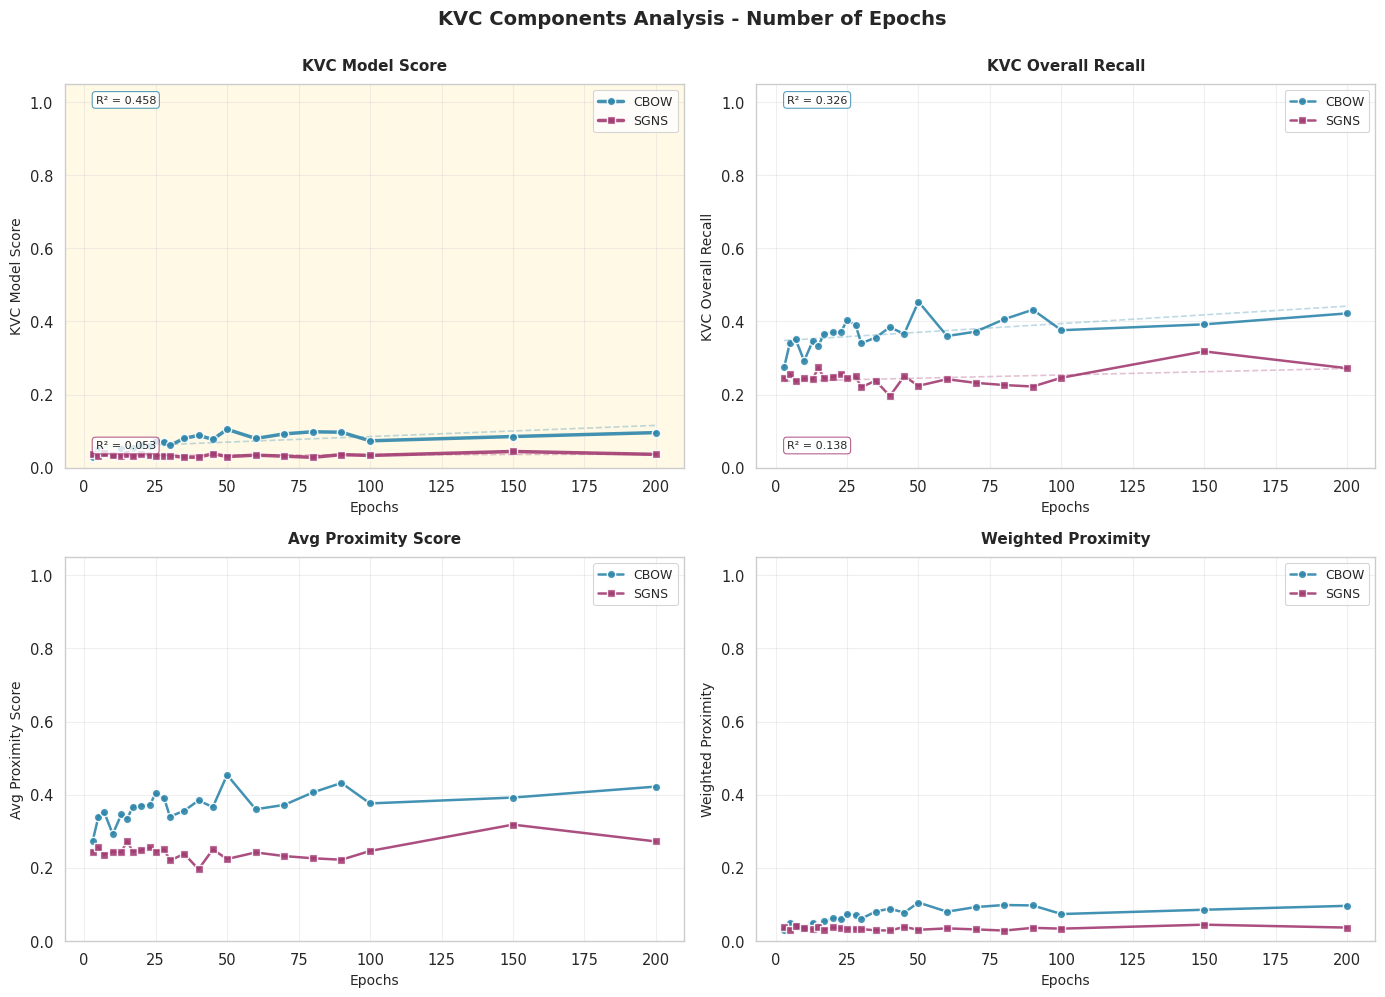

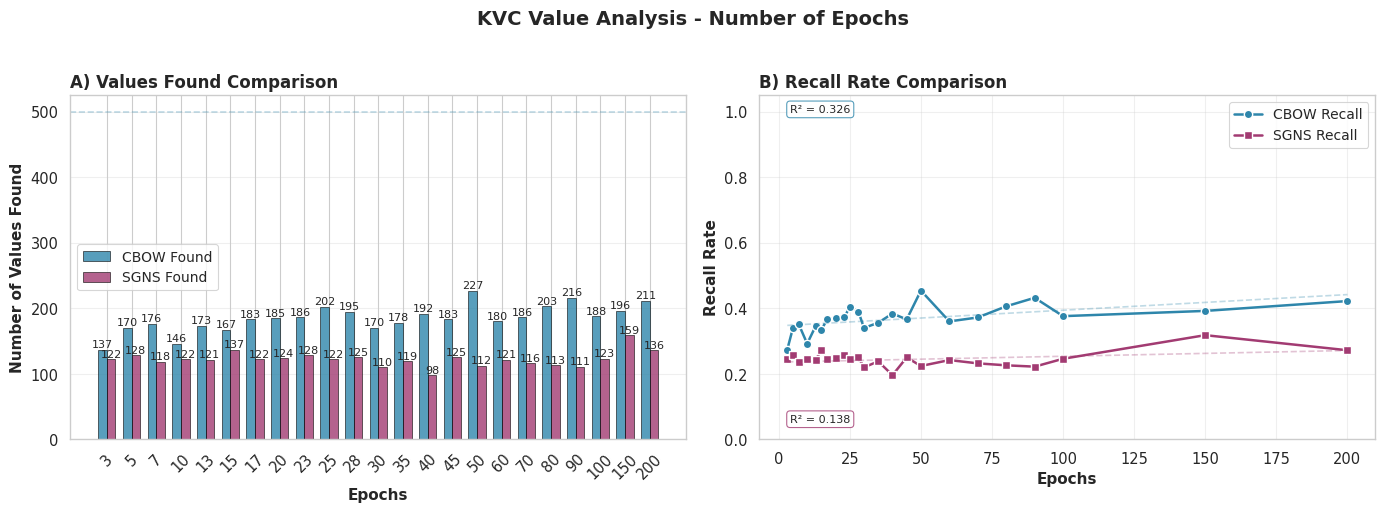


KVC NUMERICAL RESULTS - NUMBER OF EPOCHS

Epochs       | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
3            | 0.0303     0.2740     0.2740     0.0303     | 0.0378     0.2440     0.2440     0.0378    
5            | 0.0491     0.3400     0.3400     0.0491     | 0.0310     0.2560     0.2560     0.0310    
7            | 0.0405     0.3520     0.3520     0.0405     | 0.0403     0.2360     0.2360     0.0403    
10           | 0.0343     0.2920     0.2920     0.0343     | 0.0361     0.2440     0.2440     0.0361    
13           | 0.0501     0.3460     0.3460     0.0501     | 0.0313     0.2420     0.2420     0.0313    
15          

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress

# Wissenschaftliches Farbschema (konsistent mit script_2)
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'KVC_MODEL': '#F18F01', # Orange für Model Score
    'KVC_RECALL': '#6A994E', # Grün für Recall
    'KVC_AVG': '#8B8C89',   # Grau für Avg Proximity
    'KVC_WEIGHTED': '#BC4B51' # Rot für Weighted Proximity
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # KVC Model Score
    'secondary': 1.8,       # KVC Recall
    'tertiary': 1.0         # Andere KVC Metriken
}

# Seaborn Style Setup (wie in script_2)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# ============================================================
# DATENVORBEREITUNG FÜR KVC-METRIKEN (AUS SCRIPT_1)
# ============================================================

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken inklusive KVC
        data_by_category[category] = {
            'CBOW': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            },
            'SGNS': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    # Extract other main metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    # Extract KVC metrics if they exist
    kvc_model_score = None
    kvc_avg_proximity = None
    kvc_weighted_proximity = None
    kvc_recall = None
    kvc_found_values = None
    kvc_possible_values = None
    kvc_keys_evaluated = None
    
    if 'kvc' in result:
        kvc_data = result['kvc']
        kvc_model_score = float(kvc_data.get('model_score', 0))
        kvc_avg_proximity = float(kvc_data.get('avg_proximity_score', 0))
        kvc_weighted_proximity = float(kvc_data.get('avg_weighted_proximity_score', 0))
        
        # Calculate recall if not directly available
        if 'overall_recall' in kvc_data:
            kvc_recall = float(kvc_data['overall_recall'])
        elif 'total_found_values' in kvc_data and 'total_possible_values' in kvc_data:
            total_found = kvc_data['total_found_values']
            total_possible = kvc_data['total_possible_values']
            kvc_recall = total_found / total_possible if total_possible > 0 else 0
        
        kvc_found_values = kvc_data.get('total_found_values', 0)
        kvc_possible_values = kvc_data.get('total_possible_values', 0)
        kvc_keys_evaluated = kvc_data.get('keys_evaluated', 0)
    
    if x_value is not None:
        # Store all available metrics
        main_metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        kvc_metrics = [
            ('kvc_model_score', kvc_model_score),
            ('kvc_avg_proximity', kvc_avg_proximity),
            ('kvc_weighted_proximity', kvc_weighted_proximity),
            ('kvc_recall', kvc_recall),
            ('kvc_found_values', kvc_found_values),
            ('kvc_possible_values', kvc_possible_values),
            ('kvc_keys_evaluated', kvc_keys_evaluated)
        ]
        
        # Store main metrics
        for metric_name, metric_value in main_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value
        
        # Store KVC metrics
        for metric_name, metric_value in kvc_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# ============================================================
# VISUALISIERUNGSFUNKTIONEN (IM STIL VON SCRIPT_2)
# ============================================================

def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu (aus script_2)"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_kvc_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: KVC Hauptergebnis (Analog zu SSMQ in script_2)
    Panel A: KVC Model Score mit Trends
    Panel B: Best Performance Comparison
    """
    cbow_kvc_data = category_data['CBOW']['kvc_model_score']
    sgns_kvc_data = category_data['SGNS']['kvc_model_score']
    
    if not cbow_kvc_data and not sgns_kvc_data:
        print(f"No KVC Model Score data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Key-Value Coherence (KVC) Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends
    if cbow_kvc_data:
        x_cbow = sorted(cbow_kvc_data.keys())
        y_cbow = [cbow_kvc_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_kvc_data:
        x_sgns = sorted(sgns_kvc_data.keys())
        y_sgns = [sgns_kvc_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('KVC Model Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) KVC Model Score Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_kvc_data and sgns_kvc_data:
        max_cbow = max(cbow_kvc_data.values())
        max_sgns = max(sgns_kvc_data.values())
        max_cbow_param = max(cbow_kvc_data, key=cbow_kvc_data.get)
        max_sgns_param = max(sgns_kvc_data, key=sgns_kvc_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best KVC Model Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        #ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nwinner: {winner}',
        #       transform=ax2.transAxes, ha='center', va='top',
        #        fontsize=10, fontweight='bold',
        #       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    return fig
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"KVC MODEL SCORE SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_kvc_data:
        print(f"CBOW Best: {max(cbow_kvc_data.values()):.4f} at {x_label}={max(cbow_kvc_data, key=cbow_kvc_data.get)}")
    if sgns_kvc_data:
        print(f"SGNS Best: {max(sgns_kvc_data.values()):.4f} at {x_label}={max(sgns_kvc_data, key=sgns_kvc_data.get)}")
    print(f"{'='*80}\n")


def plot_kvc_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: KVC Komponenten-Analyse (Analog zu SSMQ Component Analysis in script_2)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'KVC Components Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Angepasste KVC-Metriken für die Panel-Darstellung
    metrics_config = [
        ('kvc_model_score', 'KVC Model Score', COLORS['KVC_MODEL'], axes[0, 0]),
        ('kvc_recall', 'KVC Overall Recall', COLORS['KVC_RECALL'], axes[0, 1]),
        ('kvc_avg_proximity', 'Avg Proximity Score', COLORS['KVC_AVG'], axes[1, 0]),
        ('kvc_weighted_proximity', 'Weighted Proximity', COLORS['KVC_WEIGHTED'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW immer in eigenem Farbton
            cbow_color = COLORS['CBOW'] if metric_key == 'kvc_model_score' else COLORS['CBOW']
            linewidth = LINEWIDTHS['primary'] if metric_key == 'kvc_model_score' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
            
            # Trendlinie für wichtige Metriken
            if metric_key in ['kvc_model_score', 'kvc_recall']:
                add_trend_analysis(x_cbow, y_cbow, ax, cbow_color, 'top')
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS immer in eigenem Farbton
            sgns_color = COLORS['SGNS'] if metric_key == 'kvc_model_score' else COLORS['SGNS']
            linewidth = LINEWIDTHS['primary'] if metric_key == 'kvc_model_score' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
            
            # Trendlinie für wichtige Metriken
            if metric_key in ['kvc_model_score', 'kvc_recall']:
                add_trend_analysis(x_sgns, y_sgns, ax, sgns_color, 'bottom')
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für KVC Model Score: Hervorhebung
            if metric_key == 'kvc_model_score':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund (wie in script_2)
        else:
            ax.text(0.5, 0.5, f'No {metric_key} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig


def plot_kvc_values_comparison(category, category_data, x_label, title_category):
    """
    FIGURE 3: KVC Values Vergleich (Verbesserte Version)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'KVC Value Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Found vs Possible Values (Grouped Bar Chart)
    x_values = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) + 
                          list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_values:
        # Get data for bar chart
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_values]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_values]
        cbow_possible = [category_data['CBOW']['kvc_possible_values'].get(x, 0) for x in x_values]
        sgns_possible = [category_data['SGNS']['kvc_possible_values'].get(x, 0) for x in x_values]
        
        x_pos = np.arange(len(x_values))
        width = 0.35
        
        # Create grouped bar chart
        bars1 = ax1.bar(x_pos - width/2, cbow_found, width, 
                       label='CBOW Found', color=COLORS['CBOW'], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
        bars2 = ax1.bar(x_pos + width/2, sgns_found, width, 
                       label='SGNS Found', color=COLORS['SGNS'], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)
        
        ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
        ax1.set_ylabel('Number of Values Found', fontsize=11, fontweight='bold')
        ax1.set_title('A) Values Found Comparison', fontsize=12, loc='left', fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(x_values, rotation=45 if len(x_values) > 5 else 0)
        ax1.legend(fontsize=10, frameon=True)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Add possible values as horizontal lines
        if any(cbow_possible):
            max_possible = max(cbow_possible)
            ax1.axhline(y=max_possible, color=COLORS['CBOW'], linestyle='--', 
                       alpha=0.3, label='Max Possible (CBOW)')
    
    else:
        ax1.text(0.5, 0.5, 'No KVC Values data', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        ax1.set_title('A) Values Found Comparison', fontsize=12, loc='left', fontweight='bold')
    
    # Panel B: Recall Rate Comparison (Line Plot)
    cbow_recall = category_data['CBOW']['kvc_recall']
    sgns_recall = category_data['SGNS']['kvc_recall']
    
    if cbow_recall or sgns_recall:
        if cbow_recall:
            x_cbow = sorted(cbow_recall.keys())
            y_cbow = [cbow_recall[x] for x in x_cbow]
            ax2.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                    linewidth=LINEWIDTHS['secondary'], markersize=6, 
                    label='CBOW Recall', markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x_cbow, y_cbow, ax2, COLORS['CBOW'], 'top')
        
        if sgns_recall:
            x_sgns = sorted(sgns_recall.keys())
            y_sgns = [sgns_recall[x] for x in x_sgns]
            ax2.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                    linewidth=LINEWIDTHS['secondary'], markersize=6, 
                    label='SGNS Recall', markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x_sgns, y_sgns, ax2, COLORS['SGNS'], 'bottom')
        
        ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
        ax2.set_ylabel('Recall Rate', fontsize=11, fontweight='bold')
        ax2.set_title('B) Recall Rate Comparison', fontsize=12, loc='left', fontweight='bold')
        ax2.legend(fontsize=10, frameon=True)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 1.05])
    else:
        ax2.text(0.5, 0.5, 'No Recall data', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('B) Recall Rate Comparison', fontsize=12, loc='left', fontweight='bold')
    
    plt.tight_layout()
    return fig


def create_kvc_summary_table(category, category_data, x_label, title_category):
    """
    Erstellt formatierte Tabelle für KVC-Metriken (konsistent mit script_2)
    """
    print(f"\n{'='*100}")
    print(f"KVC NUMERICAL RESULTS - {title_category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['kvc_model_score', 'kvc_recall', 'kvc_avg_proximity', 'kvc_weighted_proximity']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No KVC data available")
        return
    
    # Header mit konsistenter Formatierung
    print(f"\n{x_label:<12} | {'CBOW':<45} | {'SGNS':<45}")
    print(f"{'':<12} | {'Model':<10} {'Recall':<10} {'Avg':<10} {'Wtd':<10} | "
          f"{'Model':<10} {'Recall':<10} {'Avg':<10} {'Wtd':<10}")
    print(f"{'':<12} | {'Score':<10} {'Rate':<10} {'Prox':<10} {'Prox':<10} | "
          f"{'Score':<10} {'Rate':<10} {'Prox':<10} {'Prox':<10}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        # CBOW Werte
        cbow_model = category_data['CBOW']['kvc_model_score'].get(x, None)
        cbow_recall = category_data['CBOW']['kvc_recall'].get(x, None)
        cbow_avg = category_data['CBOW']['kvc_avg_proximity'].get(x, None)
        cbow_wtd = category_data['CBOW']['kvc_weighted_proximity'].get(x, None)
        
        # SGNS Werte
        sgns_model = category_data['SGNS']['kvc_model_score'].get(x, None)
        sgns_recall = category_data['SGNS']['kvc_recall'].get(x, None)
        sgns_avg = category_data['SGNS']['kvc_avg_proximity'].get(x, None)
        sgns_wtd = category_data['SGNS']['kvc_weighted_proximity'].get(x, None)
        
        def fmt(val):
            if val is None:
                return "N/A"
            return f"{val:.4f}" if isinstance(val, (int, float)) else str(val)
        
        print(f"{str(x):<12} | {fmt(cbow_model):<10} {fmt(cbow_recall):<10} "
              f"{fmt(cbow_avg):<10} {fmt(cbow_wtd):<10} | "
              f"{fmt(sgns_model):<10} {fmt(sgns_recall):<10} "
              f"{fmt(sgns_avg):<10} {fmt(sgns_wtd):<10}")
    
    # Value Counts Tabelle (separat)
    print(f"\n{'='*80}")
    print(f"KVC VALUE COUNTS - {title_category.upper()}")
    print(f"{'='*80}")
    
    print(f"\n{x_label:<12} | {'CBOW':<30} | {'SGNS':<30}")
    print(f"{'':<12} | {'Found':<10} {'Possible':<10} {'Keys':<10} | "
          f"{'Found':<10} {'Possible':<10} {'Keys':<10}")
    print("-" * 80)
    
    for x in sorted_x:
        # CBOW value counts
        cbow_found = category_data['CBOW']['kvc_found_values'].get(x, "N/A")
        cbow_possible = category_data['CBOW']['kvc_possible_values'].get(x, "N/A")
        cbow_keys = category_data['CBOW']['kvc_keys_evaluated'].get(x, "N/A")
        
        # SGNS value counts
        sgns_found = category_data['SGNS']['kvc_found_values'].get(x, "N/A")
        sgns_possible = category_data['SGNS']['kvc_possible_values'].get(x, "N/A")
        sgns_keys = category_data['SGNS']['kvc_keys_evaluated'].get(x, "N/A")
        
        def fmt_count(val):
            return str(val) if val != "N/A" else "N/A"
        
        print(f"{str(x):<12} | {fmt_count(cbow_found):<10} {fmt_count(cbow_possible):<10} "
              f"{fmt_count(cbow_keys):<10} | "
              f"{fmt_count(sgns_found):<10} {fmt_count(sgns_possible):<10} "
              f"{fmt_count(sgns_keys):<10}")
    
    print(f"{'='*100}\n")


# ============================================================
# HAUPTSCHEIFE FÜR DIE VISUALISIERUNG
# ============================================================

print("\n" + "="*100)
print("KEY-VALUE COHERENCE (KVC) ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping (konsistent mit script_2)
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # Prüfe ob KVC-Daten vorhanden sind
    has_kvc_data = False
    for algorithm in ['CBOW', 'SGNS']:
        if category_data[algorithm]['kvc_model_score']:
            has_kvc_data = True
            break
    
    if not has_kvc_data:
        print(f"  No KVC data available for category: {title_category}")
        print(f"  Skipping KVC visualizations...\n")
        continue
    
    # FIGURE 1: Haupt-KVC Ergebnis
    plt1 = plot_kvc_main_result(category, category_data, x_label, title_category)
    render_figure(plt1, f"KVC_main_result_{category}")
    
    # FIGURE 2: KVC Komponenten-Analyse
    plt2 = plot_kvc_component_analysis(category, category_data, x_label, title_category)
    render_figure(plt2, f"KVC_component_analysis_{category}")
    
    # FIGURE 3: KVC Values Vergleich
    plt3 = plot_kvc_values_comparison(category, category_data, x_label, title_category)
    render_figure(plt3, f"KVC_values_comparison_{category}")
    
    # TABLE: Numerische Ergebnisse
    create_kvc_summary_table(category, category_data, x_label, title_category)

print("\n" + "="*100)
print("KVC ANALYSIS COMPLETE")
print("="*100)


TOP 10 WORD2VEC MODELS BY SSMQ SCORE



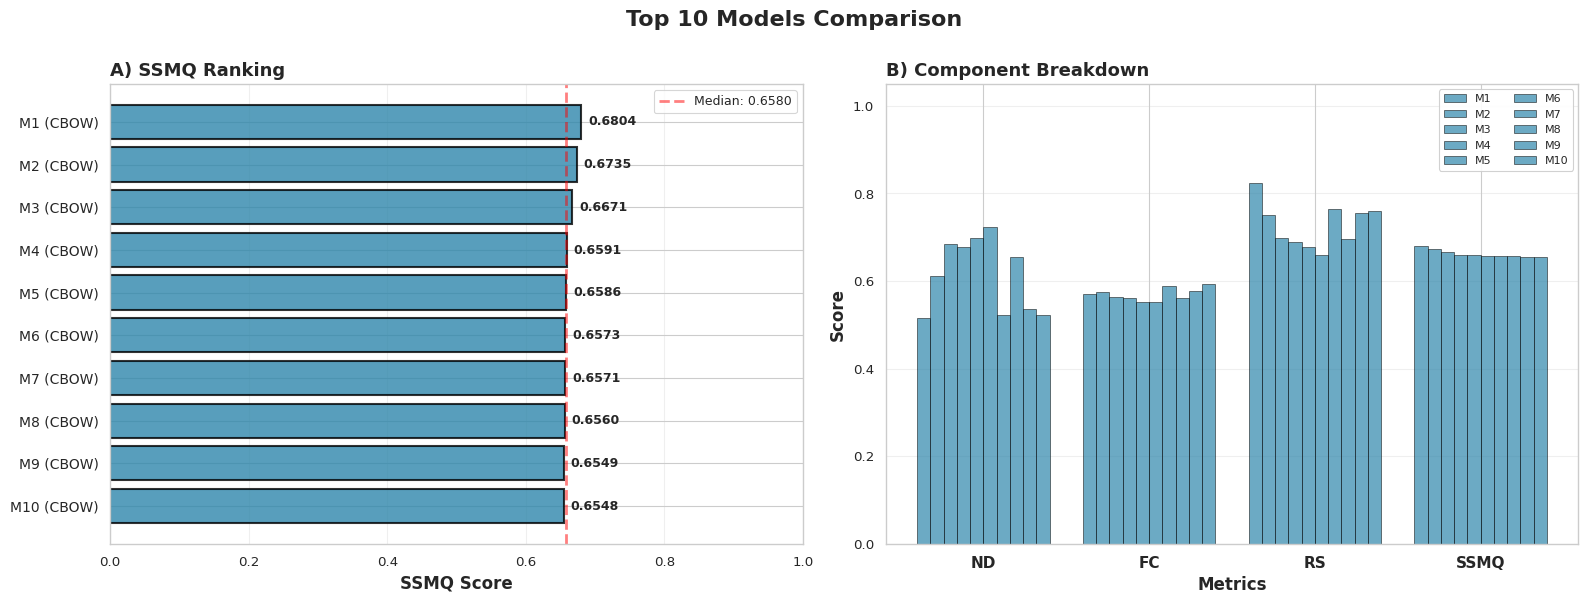

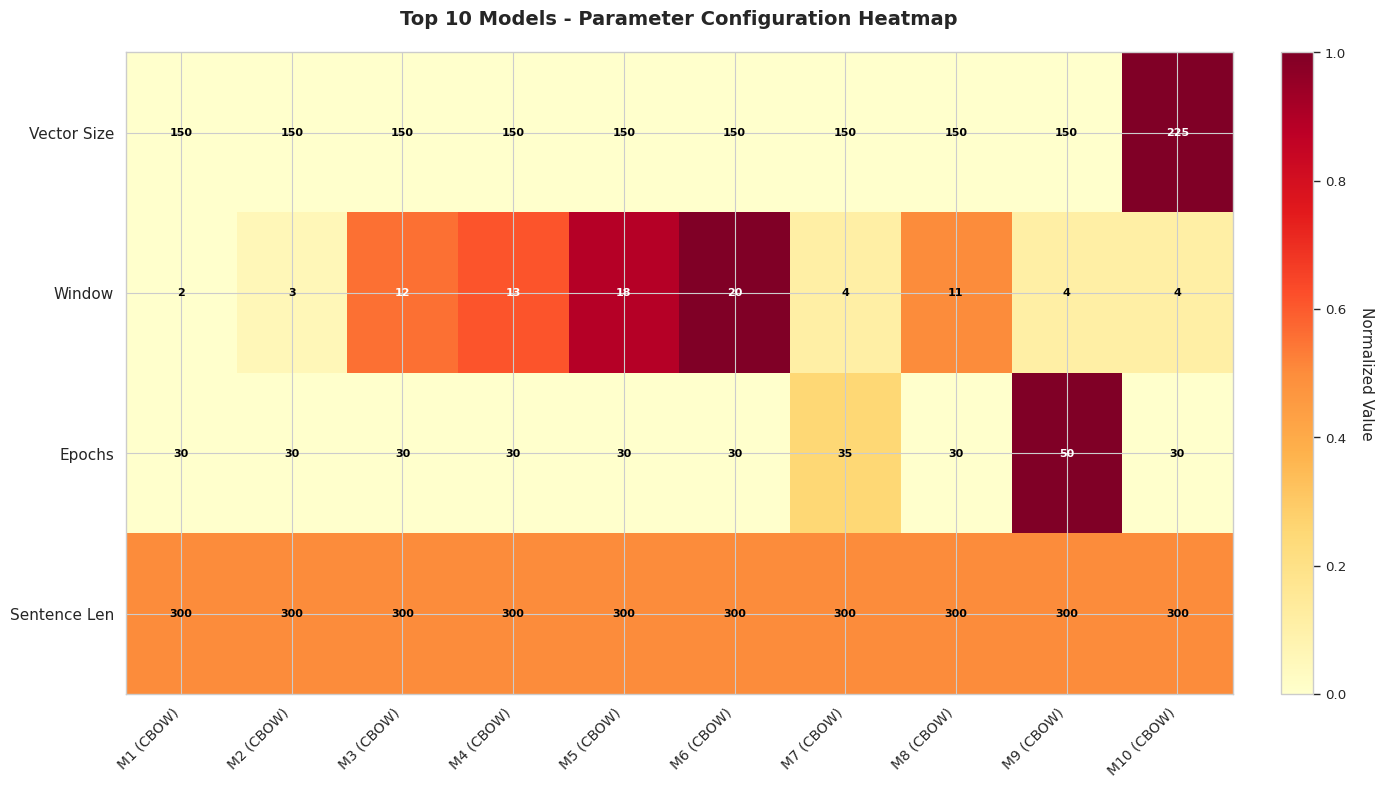


TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)

Model Algorithm   SSMQ     ND     FC     RS  Vec  Win  Epoch
   M1      CBOW 0.6804 0.5157 0.5698 0.8235  150    2     30
   M2      CBOW 0.6735 0.6115 0.5751 0.7500  150    3     30
   M3      CBOW 0.6671 0.6855 0.5629 0.6977  150   12     30
   M4      CBOW 0.6591 0.6767 0.5604 0.6880  150   13     30
   M5      CBOW 0.6586 0.6985 0.5515 0.6775  150   18     30
   M6      CBOW 0.6573 0.7232 0.5520 0.6599  150   20     30
   M7      CBOW 0.6571 0.5218 0.5893 0.7654  150    4     35
   M8      CBOW 0.6560 0.6537 0.5609 0.6955  150   11     30
   M9      CBOW 0.6549 0.5373 0.5779 0.7562  150    4     50
  M10      CBOW 0.6548 0.5216 0.5938 0.7591  225    4     30


LaTeX Table Code:
--------------------------------------------------------------------------------
\begin{tabular}{llllllrrr}
\toprule
Model & Algorithm & SSMQ & ND & FC & RS & Vec & Win & Epoch \\
\midrule
M1 & CBOW & 0.6804 & 0.5157 & 0.5698 & 0.8235 & 150 & 2 & 30 \\
M2 & CBOW 

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'SSMQ': '#F18F01',
    'ND': '#6A994E',
    'FC': '#BC4B51',
    'RS': '#8B8C89'
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Sammle alle Modelle mit ihren SSMQ-Werten und Parametern
# ==================================================================================

models_list = []

for result in test_results:
    # SSMQ-Wert extrahieren
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue  # Überspringe Modelle ohne SSMQ
    
    # Parameter extrahieren
    params = result['params']
    algorithm = params.get('Algorithmus', 'Unknown')
    
    # Alle Metriken sammeln
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': algorithm,
        'vector_size': params.get('Vector Size', 'N/A'),
        'window': params.get('Window', 'N/A'),
        'epochs': params.get('Epochs', 'N/A'),
        'sentence_length': params.get('Satzlänge', 'N/A'),
        'negative': params.get('Negative Sampling', 'N/A'),
        'sample': params.get('Sample', 'N/A'),
        'alpha': params.get('Alpha', 'N/A'),
        'hs': params.get('Hierarchical Softmax', 'N/A'),
    }
    
    models_list.append(model_data)

# ==================================================================================
# SCHRITT 2: Sortiere nach SSMQ und wähle Top 10
# ==================================================================================

models_sorted = sorted(models_list, key=lambda x: x['ssmq'], reverse=True)
top10_models = models_sorted[:10]

print("\n" + "="*120)
print("TOP 10 WORD2VEC MODELS BY SSMQ SCORE")
print("="*120 + "\n")

# ==================================================================================
# SCHRITT 3: Erstelle Model-IDs und Parameter-Tabelle
# ==================================================================================

model_ids = []
model_labels = []
model_colors = []

for i, model in enumerate(top10_models, 1):
    model_id = f"M{i}"
    model_ids.append(model_id)
    
    # Farbe basierend auf Algorithmus
    color = COLORS['CBOW'] if model['algorithm'] == 'CBOW' else COLORS['SGNS']
    model_colors.append(color)
    
    # Kurze Label für Plot
    label = f"{model_id} ({model['algorithm']})"
    model_labels.append(label)

# ==================================================================================
# FIGURE 1: Metriken-Vergleich (Radar Plot Style mit Bars)
# ==================================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Models Comparison', fontsize=16, fontweight='bold', y=1.00)

# Panel A: SSMQ Ranking
ssmq_scores = [model['ssmq'] for model in top10_models]
x_pos = np.arange(len(model_ids))

bars = ax1.barh(x_pos, ssmq_scores, color=model_colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

# Werte auf Balken
for i, (bar, score, model) in enumerate(zip(bars, ssmq_scores, top10_models)):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{score:.4f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(x_pos)
ax1.set_yticklabels(model_labels, fontsize=10)
ax1.invert_yaxis()  # Bestes Modell oben
ax1.set_xlabel('SSMQ Score', fontsize=12, fontweight='bold')
ax1.set_title('A) SSMQ Ranking', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, 1.0])

# Trennlinie bei Median
median_ssmq = np.median(ssmq_scores)
ax1.axvline(median_ssmq, color='red', linestyle='--', linewidth=2, 
           alpha=0.5, label=f'Median: {median_ssmq:.4f}')
ax1.legend(fontsize=9)

# Panel B: Component Breakdown (alle Metriken für Top 10)
metrics = ['ND', 'FC', 'RS', 'SSMQ']
x_metrics = np.arange(len(metrics))
bar_width = 0.08  # Schmale Balken für 10 Modelle

for i, model in enumerate(top10_models):
    values = [model['nd'], model['fc'], model['rs_mean'], model['ssmq']]
    offset = (i - 4.5) * bar_width  # Zentriere die Balken
    
    ax2.bar(x_metrics + offset, values, bar_width, 
           label=model_ids[i], color=model_colors[i], 
           alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('B) Component Breakdown', fontsize=13, fontweight='bold', loc='left')
ax2.set_xticks(x_metrics)
ax2.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=8, ncol=2, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
render_figure(fig, f"Radar_Plot_{category}")


# ==================================================================================
# FIGURE 2: Detaillierte Parameter-Heatmap
# ==================================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Erstelle Parameter-Matrix für Heatmap (ohne negative, sample, alpha)
param_names = ['Vector Size', 'Window', 'Epochs', 'Sentence Len']
param_keys = ['vector_size', 'window', 'epochs', 'sentence_length']

# Normalisiere Parameter für Heatmap (0-1 Skala)
param_matrix = []
param_raw_matrix = []

for model in top10_models:
    row = []
    raw_row = []
    for key in param_keys:
        val = model[key]
        raw_row.append(val)
        # Versuche numerischen Wert zu extrahieren
        try:
            num_val = float(val)
            row.append(num_val)
        except:
            row.append(0)
    param_matrix.append(row)
    param_raw_matrix.append(raw_row)

param_matrix = np.array(param_matrix)

# Normalisiere jede Spalte auf [0, 1]
param_matrix_norm = np.zeros_like(param_matrix)
for col in range(param_matrix.shape[1]):
    col_data = param_matrix[:, col]
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        param_matrix_norm[:, col] = (col_data - col_min) / (col_max - col_min)
    else:
        param_matrix_norm[:, col] = 0.5  # Alle gleich

# Erstelle Heatmap
im = ax.imshow(param_matrix_norm.T, cmap='YlOrRd', aspect='auto', 
              vmin=0, vmax=1, interpolation='nearest')

# Achsenbeschriftungen
ax.set_xticks(np.arange(len(model_ids)))
ax.set_yticks(np.arange(len(param_names)))
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(param_names, fontsize=11)

# Zeige tatsächliche Werte in Zellen
for i in range(len(model_ids)):
    for j in range(len(param_names)):
        text_val = param_raw_matrix[i][j]
        # Textfarbe basierend auf Helligkeit
        color = 'white' if param_matrix_norm[i, j] > 0.5 else 'black'
        ax.text(i, j, str(text_val), ha='center', va='center', 
               color=color, fontsize=8, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Value', rotation=270, labelpad=20, fontsize=11)

ax.set_title('Top 10 Models - Parameter Configuration Heatmap', 
            fontsize=14, fontweight='bold', pad=20)

# Trennlinie zwischen CBOW und SGNS (falls vorhanden)
cbow_count = sum(1 for m in top10_models if m['algorithm'] == 'CBOW')
if 0 < cbow_count < len(top10_models):
    ax.axvline(cbow_count - 0.5, color='blue', linewidth=3, alpha=0.6)
    ax.text(cbow_count/2 - 0.5, -0.8, 'CBOW', ha='center', fontsize=12, 
           fontweight='bold', color=COLORS['CBOW'])
    ax.text(cbow_count + (len(top10_models) - cbow_count)/2 - 0.5, -0.8, 
           'SGNS', ha='center', fontsize=12, fontweight='bold', 
           color=COLORS['SGNS'])

plt.tight_layout()
plt.show()

# ==================================================================================
# SUMMARY TABLE: Export-ready
# ==================================================================================

print("\n" + "="*120)
print("TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)")
print("="*120 + "\n")

# Erstelle DataFrame
df_data = []
for i, model in enumerate(top10_models, 1):
    df_data.append({
        'Model': f'M{i}',
        'Algorithm': model['algorithm'],
        'SSMQ': f"{model['ssmq']:.4f}",
        'ND': f"{model['nd']:.4f}",
        'FC': f"{model['fc']:.4f}",
        'RS': f"{model['rs_mean']:.4f}",
        'Vec': model['vector_size'],
        'Win': model['window'],
        'Epoch': model['epochs']
    })

df = pd.DataFrame(df_data)
print(df.to_string(index=False))
print("\n" + "="*120 + "\n")

# Optional: LaTeX Export
try:
    latex_table = df.to_latex(index=False, float_format="%.4f")
    print("LaTeX Table Code:")
    print("-" * 80)
    print(latex_table)
except:
    print("(pandas LaTeX export not available)")

print("\n" + "="*120)
print("ANALYSIS COMPLETE - Top 10 Models Identified and Visualized")
print("="*120)


SELECTED MODELS COMPARISON (Best & Worst per algorithm)

BEST CBOW MODEL:
  CBOW | SSMQ: 0.6804 | Vec: 150, Win: 2, Epochs: 30

WORST CBOW MODEL:
  CBOW | SSMQ: 0.4694 | Vec: 60, Win: 4, Epochs: 30

BEST SGNS MODEL:
  SGNS | SSMQ: 0.5666 | Vec: 150, Win: 4, Epochs: 30

WORST SGNS MODEL:
  SGNS | SSMQ: 0.1946 | Vec: 20, Win: 4, Epochs: 30

EXTRACTING WORD AND SENTENCE VECTORS...

CBOW Best Model:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 150 dims
   Female: 13629 female, 16371 not

CBOW Worst Model:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 60 dims
   Female: 13629 female, 16371 not

SGNS Best Model:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 150 dims
   Female: 13629 female, 16371 not

SGNS Worst Model:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 20 dims
   Female: 13629 female, 16371 not

CREATING WORD VECTOR VISUALIZATIONS

  CBOW Best: 51 

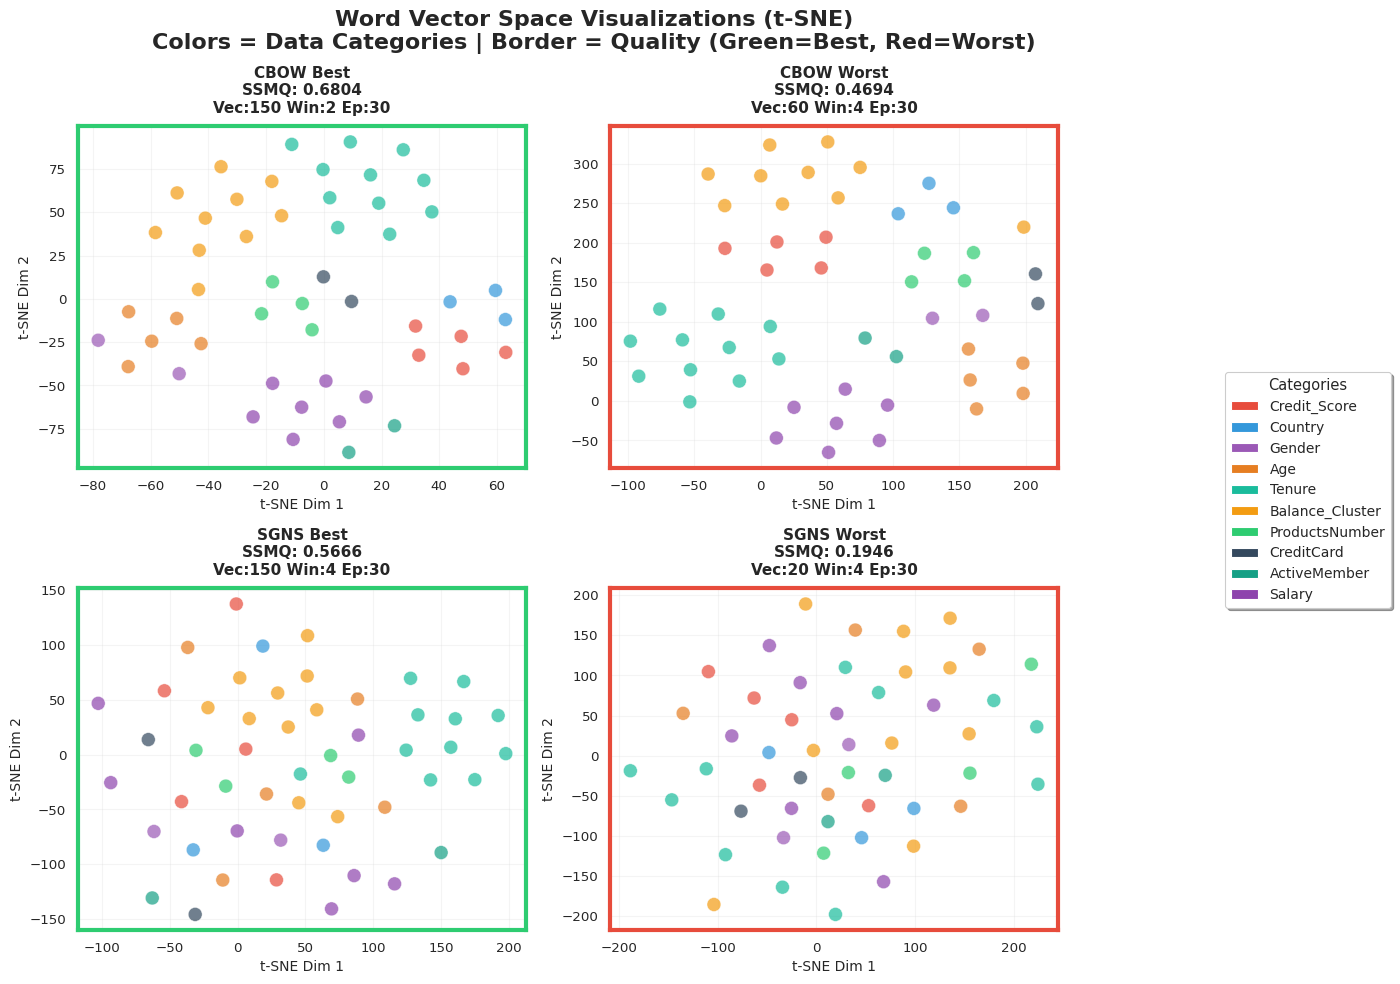


CREATING SENTENCE VECTOR VISUALIZATIONS

  CBOW Best: 1500 sentences
  CBOW Worst: 1500 sentences
  SGNS Best: 1500 sentences
  SGNS Worst: 1500 sentences


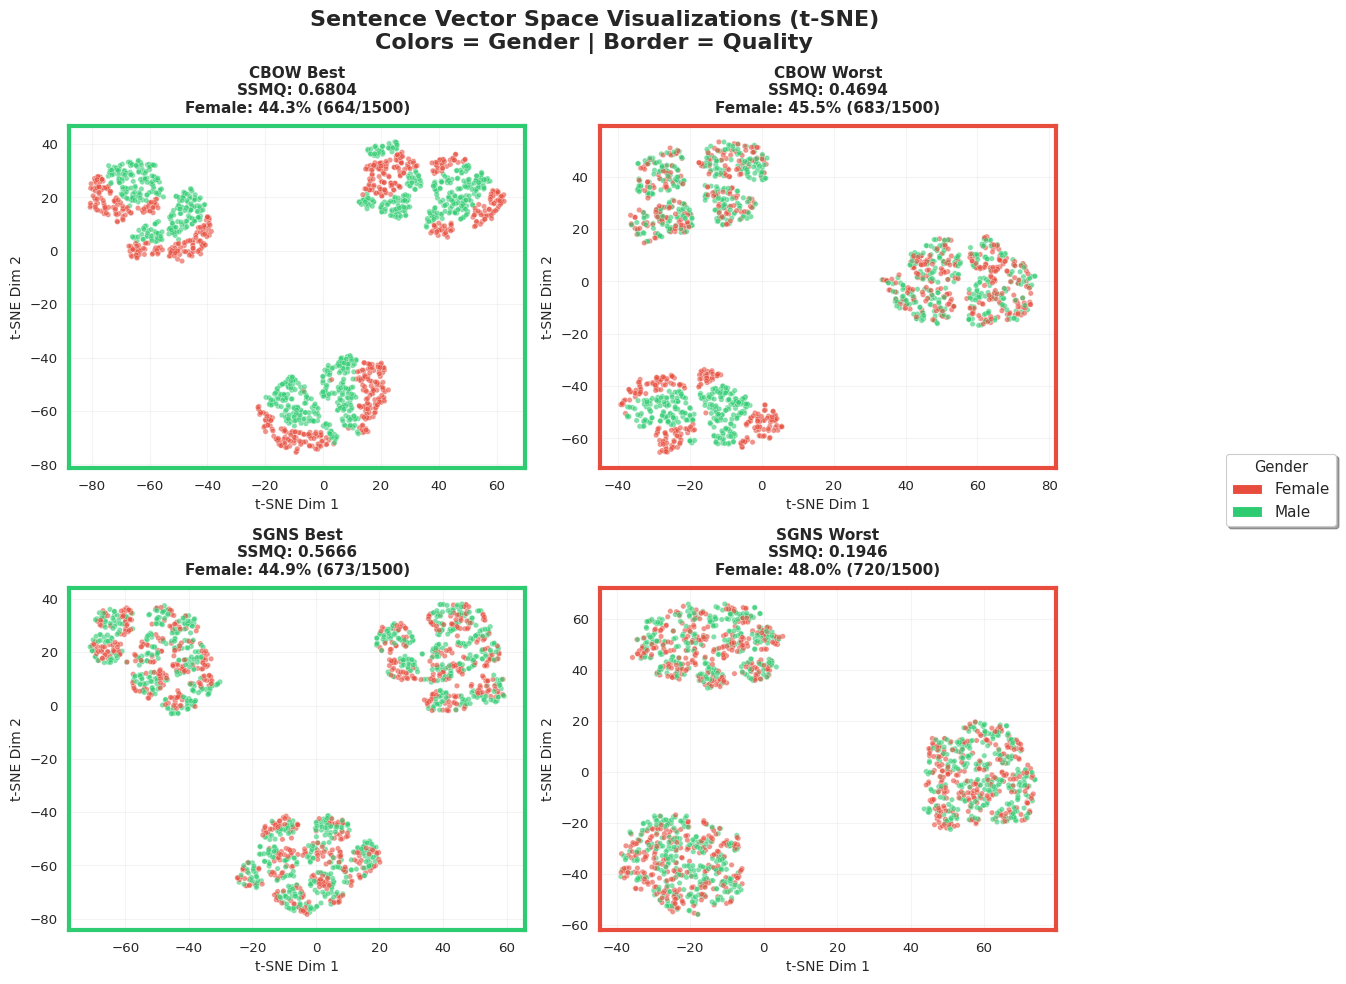

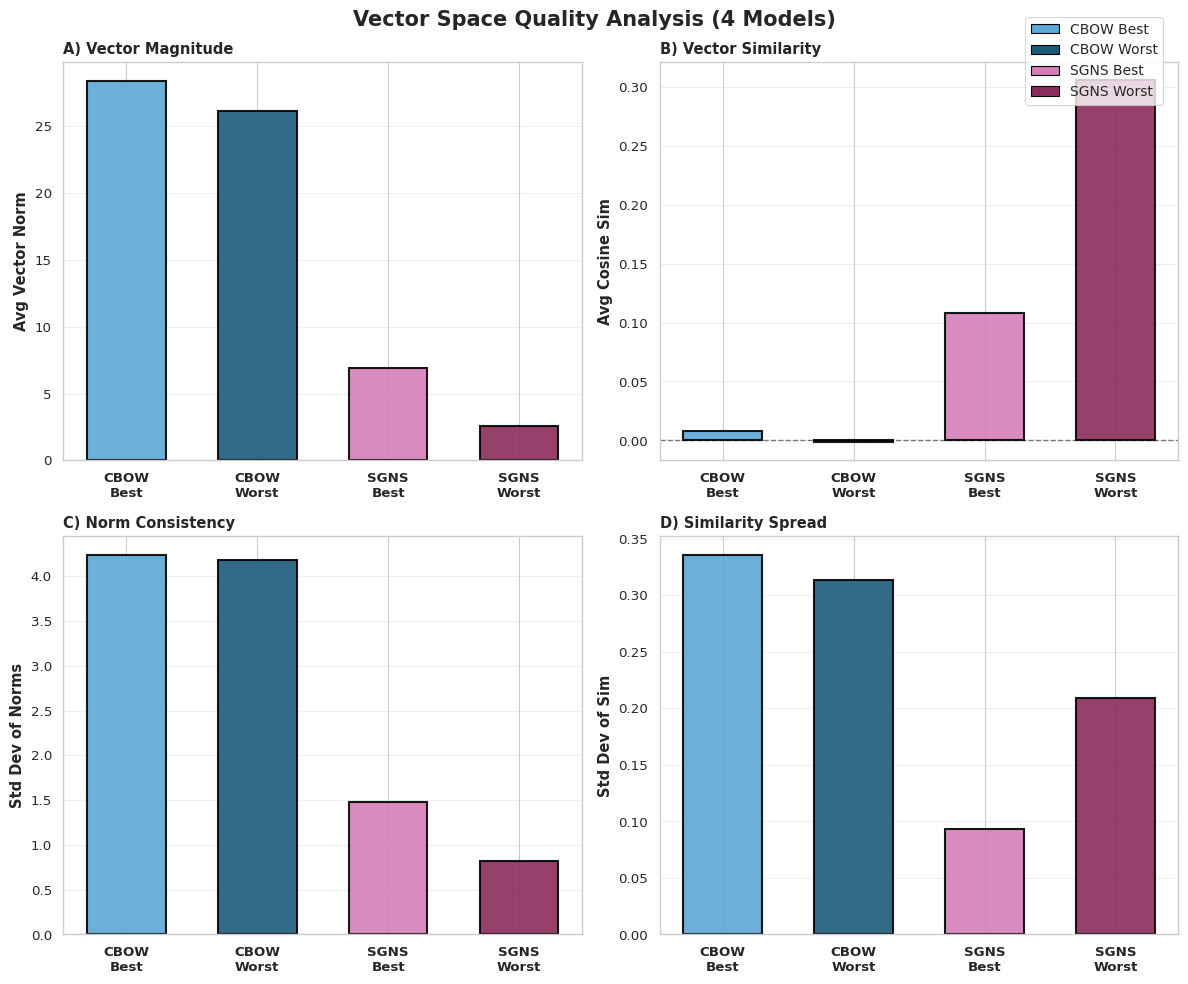


ALGORITHM COMPARISON COMPLETE


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Finde BESTES und SCHLECHTESTES CBOW- und SGNS-Modell
# ==================================================================================

models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähje NUR BESTES und SCHLECHTESTES für jeden Algorithmus
best_cbow = cbow_sorted[0] if len(cbow_sorted) > 0 else None
worst_cbow = cbow_sorted[-1] if len(cbow_sorted) > 0 else None
best_sgns = sgns_sorted[0] if len(sgns_sorted) > 0 else None
worst_sgns = sgns_sorted[-1] if len(sgns_sorted) > 0 else None

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (Best & Worst per algorithm)")
print("="*100 + "\n")

if best_cbow:
    print("BEST CBOW MODEL:")
    print(f"  CBOW | SSMQ: {best_cbow['ssmq']:.4f} | "
          f"Vec: {best_cbow['vector_size']}, Win: {best_cbow['window']}, Epochs: {best_cbow['epochs']}")

if worst_cbow:
    print("\nWORST CBOW MODEL:")
    print(f"  CBOW | SSMQ: {worst_cbow['ssmq']:.4f} | "
          f"Vec: {worst_cbow['vector_size']}, Win: {worst_cbow['window']}, Epochs: {worst_cbow['epochs']}")

if best_sgns:
    print("\nBEST SGNS MODEL:")
    print(f"  SGNS | SSMQ: {best_sgns['ssmq']:.4f} | "
          f"Vec: {best_sgns['vector_size']}, Win: {best_sgns['window']}, Epochs: {best_sgns['epochs']}")

if worst_sgns:
    print("\nWORST SGNS MODEL:")
    print(f"  SGNS | SSMQ: {worst_sgns['ssmq']:.4f} | "
          f"Vec: {worst_sgns['vector_size']}, Win: {worst_sgns['window']}, Epochs: {worst_sgns['epochs']}")

# ==================================================================================
# HILFSFUNKTIONEN
# ==================================================================================

def extract_word_vectors(model_data):
    """Extrahiert Word Vectors und filtert key_* Wörter"""
    result = model_data['result_ref']
    
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            all_vocab = list(model.wv.key_to_index.keys())
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert")
                return None, None
            
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total: {len(all_vocab)}, Filtered: {filtered_count}, Kept: {len(filtered_vocab)}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden")
    return None, None


def extract_sentence_vectors(model_data):
    """Extrahiert Satzvektoren und Gener-Labels"""
    result = model_data['result_ref']
    
    if 'used_sentence_vectors' in result and 'data' in result['used_sentence_vectors']:
        data_tuples = result['used_sentence_vectors']['data']
        
        if not data_tuples:
            print(f"   No sentence vectors found")
            return None, None
        
        all_vectors = []
        all_labels = []
        
        for seed_id, df in data_tuples:
            vectors = np.array([np.array(v) for v in df['vector'].values])
            labels = df['female'].values
            all_vectors.append(vectors)
            all_labels.append(labels)
        
        combined_vectors = np.vstack(all_vectors)
        combined_labels = np.concatenate(all_labels)
        
        print(f"   Sentence vectors: {combined_vectors.shape[0]} samples, {combined_vectors.shape[1]} dims")
        print(f"   Female: {np.sum(combined_labels)} female, {len(combined_labels) - np.sum(combined_labels)} not")
        
        return combined_vectors, combined_labels
    
    print(f"   No sentence vectors available")
    return None, None


def get_category_color(word):
    """Bestimmt Farbe basierend auf Datenkategorie"""
    category_colors = {
        'Credit_Score': '#E74C3C',
        'Country': '#3498DB',
        'Gender': '#9B59B6',
        'Age': '#E67E22',
        'Tenure': '#1ABC9C',
        'Balance_Cluster': '#F39C12',
        'ProductsNumber': '#2ECC71',
        'CreditCard': '#34495E',
        'ActiveMember': '#16A085',
        'Salary': '#8E44AD',
        'Churn': '#C0392B',
    }
    
    parts = word.split('_')
    
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    elif len(parts) >= 1:
        category = parts[0]
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    return category_colors.get(category, '#95A5A6')


def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# ==================================================================================
# DATENEXTRAKTION
# ==================================================================================

print("\n" + "="*100)
print("EXTRACTING WORD AND SENTENCE VECTORS...")
print("="*100 + "\n")

# Initialisiere Variablen
selected_models = []
word_data = []  # Für Word Vectors
sent_data = []  # Für Sentence Vectors

# CBOW Best
if best_cbow:
    print("CBOW Best Model:")
    vectors, vocab = extract_word_vectors(best_cbow)
    sent_vec, sent_lab = extract_sentence_vectors(best_cbow)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': best_cbow, 'algorithm': 'CBOW', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'CB-B'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': best_cbow, 'algorithm': 'CBOW', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'CB-B'
        })

# CBOW Worst
if worst_cbow:
    print("\nCBOW Worst Model:")
    vectors, vocab = extract_word_vectors(worst_cbow)
    sent_vec, sent_lab = extract_sentence_vectors(worst_cbow)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': worst_cbow, 'algorithm': 'CBOW', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'CB-W'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': worst_cbow, 'algorithm': 'CBOW', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'CB-W'
        })

# SGNS Best
if best_sgns:
    print("\nSGNS Best Model:")
    vectors, vocab = extract_word_vectors(best_sgns)
    sent_vec, sent_lab = extract_sentence_vectors(best_sgns)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': best_sgns, 'algorithm': 'SGNS', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'SG-B'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': best_sgns, 'algorithm': 'SGNS', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'SG-B'
        })

# SGNS Worst
if worst_sgns:
    print("\nSGNS Worst Model:")
    vectors, vocab = extract_word_vectors(worst_sgns)
    sent_vec, sent_lab = extract_sentence_vectors(worst_sgns)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': worst_sgns, 'algorithm': 'SGNS', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'SG-W'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': worst_sgns, 'algorithm': 'SGNS', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'SG-W'
        })

# ==================================================================================
# FIGURE 1: WORD VECTORS (4 Plots - 1 pro Modell)
# ==================================================================================
            
if word_data:
    print(f"\n{'='*100}")
    print("CREATING WORD VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    # 2x2 Grid statt 1x4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Word Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Data Categories | Border = Quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    axes = axes.flatten()  # Wichtig: flatten für einfache Iteration
    
    for idx, model_data in enumerate(word_data):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']}: {max_words} words")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), 
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0, 
                   learning_rate=300, metric='cosine')
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        title = f"{model_data['algorithm']} {model_data['quality']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    # Verstecke leere Axes
    for idx in range(len(word_data), len(axes)):
        axes[idx].set_visible(False)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        #Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.02, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    render_figure(fig, f"Word_Vectors_Comparison")

# ==================================================================================
# FIGURE 2: SENTENCE VECTORS (4 Plots - 1 pro Modell)
# ==================================================================================

if sent_data:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    # 2x2 Grid statt 1x4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Sentence Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Gender | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    axes = axes.flatten()  
    
    gender_colors = {True: '#E74C3C', False: '#2ECC71'}
    
    for idx, model_data in enumerate(sent_data):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']}: {max_sent} sentences")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), 
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0, 
                   learning_rate=100, metric='cosine')
        
        #TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [gender_colors[label] for label in labels_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        gender_count = np.sum(labels_sample)
        gender_rate = gender_count / len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Female: {gender_rate:.1%} ({gender_count}/{len(labels_sample)})"
        
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    # Verstecke leere Axes
    for idx in range(len(sent_data), len(axes)):
        axes[idx].set_visible(False)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=gender_colors[True], label='Female'),
        Patch(facecolor=gender_colors[False], label='Male'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.02, 0.5), fontsize=11, title='Gender',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    render_figure(fig, f"Sentence_Vectors_Comparison")

# ==================================================================================
# FIGURE 3: VECTOR SPACE QUALITY METRICS
# ==================================================================================

if word_data:
    all_stats = []
    all_labels = []
    bar_colors = []
    
    for model_data in word_data:
        vectors = model_data['vectors']
        stats = compute_vector_statistics(vectors)
        all_stats.append(stats)
        all_labels.append(model_data['label'])
        
        # Bestimme Farbe basierend auf Algorithmus und Qualität
        if model_data['algorithm'] == 'CBOW':
            if model_data['quality'] == 'Best':
                bar_colors.append('#5CA8D6')  # Hellblau für CBOW Best
            else:
                bar_colors.append('#1A5B7A')  # Dunkelblau für CBOW Worst
        else:  # SGNS
            if model_data['quality'] == 'Best':
                bar_colors.append('#D67EB8')  # Hellrosa für SGNS Best
            else:
                bar_colors.append('#8A2C5C')  # Dunkelrosa für SGNS Worst
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Vector Space Quality Analysis (4 Models)', fontsize=15, fontweight='bold', y=0.98)
    
    # Bessere x-tick labels
    xtick_labels = []
    for label in all_labels:
        if label == 'CB-B':
            xtick_labels.append('CBOW\nBest')
        elif label == 'CB-W':
            xtick_labels.append('CBOW\nWorst')
        elif label == 'SG-B':
            xtick_labels.append('SGNS\nBest')
        elif label == 'SG-W':
            xtick_labels.append('SGNS\nWorst')
    
    # Plot metrics
    axes[0, 0].bar(range(len(all_labels)), [s['avg_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[0, 0].set_title('A) Vector Magnitude', fontweight='bold', loc='left')
    axes[0, 0].set_ylabel('Avg Vector Norm', fontweight='bold')
    axes[0, 0].set_xticks(range(len(all_labels)))
    axes[0, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    axes[0, 1].bar(range(len(all_labels)), [s['avg_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[0, 1].set_title('B) Vector Similarity', fontweight='bold', loc='left')
    axes[0, 1].set_ylabel('Avg Cosine Sim', fontweight='bold')
    axes[0, 1].set_xticks(range(len(all_labels)))
    axes[0, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    axes[1, 0].bar(range(len(all_labels)), [s['std_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[1, 0].set_title('C) Norm Consistency', fontweight='bold', loc='left')
    axes[1, 0].set_ylabel('Std Dev of Norms', fontweight='bold')
    axes[1, 0].set_xticks(range(len(all_labels)))
    axes[1, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    axes[1, 1].bar(range(len(all_labels)), [s['std_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[1, 1].set_title('D) Similarity Spread', fontweight='bold', loc='left')
    axes[1, 1].set_ylabel('Std Dev of Sim', fontweight='bold')
    axes[1, 1].set_xticks(range(len(all_labels)))
    axes[1, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    render_figure(fig, f"Vector_Space_Metrics_Comparison")

print("\n" + "="*100)
print("ALGORITHM COMPARISON COMPLETE")
print("="*100)

### import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Finde BESTES und SCHLECHTESTES CBOW- und SGNS-Modell
# ==================================================================================

models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähje NUR BESTES und SCHLECHTESTES für jeden Algorithmus
best_cbow = cbow_sorted[0] if len(cbow_sorted) > 0 else None
worst_cbow = cbow_sorted[-1] if len(cbow_sorted) > 0 else None
best_sgns = sgns_sorted[0] if len(sgns_sorted) > 0 else None
worst_sgns = sgns_sorted[-1] if len(sgns_sorted) > 0 else None

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (Best & Worst per algorithm)")
print("="*100 + "\n")

if best_cbow:
    print("BEST CBOW MODEL:")
    print(f"  CBOW | SSMQ: {best_cbow['ssmq']:.4f} | "
          f"Vec: {best_cbow['vector_size']}, Win: {best_cbow['window']}, Epochs: {best_cbow['epochs']}")

if worst_cbow:
    print("\nWORST CBOW MODEL:")
    print(f"  CBOW | SSMQ: {worst_cbow['ssmq']:.4f} | "
          f"Vec: {worst_cbow['vector_size']}, Win: {worst_cbow['window']}, Epochs: {worst_cbow['epochs']}")

if best_sgns:
    print("\nBEST SGNS MODEL:")
    print(f"  SGNS | SSMQ: {best_sgns['ssmq']:.4f} | "
          f"Vec: {best_sgns['vector_size']}, Win: {best_sgns['window']}, Epochs: {best_sgns['epochs']}")

if worst_sgns:
    print("\nWORST SGNS MODEL:")
    print(f"  SGNS | SSMQ: {worst_sgns['ssmq']:.4f} | "
          f"Vec: {worst_sgns['vector_size']}, Win: {worst_sgns['window']}, Epochs: {worst_sgns['epochs']}")

# ==================================================================================
# HILFSFUNKTIONEN
# ==================================================================================

def extract_word_vectors(model_data):
    """Extrahiert Word Vectors und filtert key_* Wörter"""
    result = model_data['result_ref']
    
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            all_vocab = list(model.wv.key_to_index.keys())
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert")
                return None, None
            
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total: {len(all_vocab)}, Filtered: {filtered_count}, Kept: {len(filtered_vocab)}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden")
    return None, None


def extract_sentence_vectors(model_data):
    """Extrahiert Satzvektoren und Country-Labels"""
    result = model_data['result_ref']
    
    if 'used_sentence_vectors' in result and 'data' in result['used_sentence_vectors']:
        data_tuples = result['used_sentence_vectors']['data']
        
        if not data_tuples:
            print(f"   No sentence vectors found")
            return None, None
        
        all_vectors = []
        all_labels = []
        
        for seed_id, df in data_tuples:
            vectors = np.array([np.array(v) for v in df['vector'].values])
            labels = df['country'].values
            
            # Die Labels sind bereits numerisch: 0=France, 1=Germany, 2=Spain
            # Keine Konvertierung notwendig!
            
            all_vectors.append(vectors)
            all_labels.extend(labels)
        
        combined_vectors = np.vstack(all_vectors)
        combined_labels = np.array(all_labels)
        
        # Zähle die verschiedenen Länder
        france_count = np.sum(combined_labels == 0)
        germany_count = np.sum(combined_labels == 1)
        spain_count = np.sum(combined_labels == 2)
        
        print(f"   Sentence vectors: {combined_vectors.shape[0]} samples, {combined_vectors.shape[1]} dims")
        print(f"   France: {france_count}, Germany: {germany_count}, Spain: {spain_count}")
        
        return combined_vectors, combined_labels
    
    print(f"   No sentence vectors available")
    return None, None


# ==================================================================================
# FIGURE 2: SENTENCE VECTORS (4 Plots - 1 pro Modell)
# ==================================================================================

if sent_data:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    # 2x2 Grid statt 1x4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Sentence Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Country | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    axes = axes.flatten()  
    
    country_colors = {
        0: "#0055A4",      # Blau für France (französische Flagge)
        1: "#000000",      # Schwarz für Germany (deutsche Flagge)  
        2: "#FFC300"       # Gold/Gelb für Spain (spanische Flagge)
    }
    
    for idx, model_data in enumerate(sent_data):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']}: {max_sent} sentences")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), 
                   max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        # Filtere ungültige Labels heraus (-1 oder andere Werte)
        valid_indices = [i for i, label in enumerate(labels_sample) if label in country_colors]
        vectors_2d_valid = vectors_2d[valid_indices]
        labels_sample_valid = labels_sample[valid_indices]
        
        if len(valid_indices) == 0:
            print(f"  ⚠️ Keine gültigen Country-Labels gefunden")
            continue
            
        point_colors = [country_colors[label] for label in labels_sample_valid]
        
        ax.scatter(vectors_2d_valid[:, 0], vectors_2d_valid[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        # Zähle die verschiedenen Länder
        france_count = np.sum(labels_sample == 0)
        germany_count = np.sum(labels_sample == 1)
        spain_count = np.sum(labels_sample == 2)
        total_count = len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"FR: {france_count} DE: {germany_count} ES: {spain_count}"
        
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    # Verstecke leere Axes
    for idx in range(len(sent_data), len(axes)):
        axes[idx].set_visible(False)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=country_colors[0], label='France'),
        Patch(facecolor=country_colors[1], label='Germany'),
        Patch(facecolor=country_colors[2], label='Spain'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.02, 0.5), fontsize=11, title='Countries',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    #render_figure(fig, f"Sentence_Vectors_Comparison")


def get_category_color(word):
    """Bestimmt Farbe basierend auf Datenkategorie"""
    category_colors = {
        'Credit_Score': '#E74C3C',
        'Country': '#3498DB',
        'Gender': '#9B59B6',
        'Age': '#E67E22',
        'Tenure': '#1ABC9C',
        'Balance_Cluster': '#F39C12',
        'ProductsNumber': '#2ECC71',
        'CreditCard': '#34495E',
        'ActiveMember': '#16A085',
        'Salary': '#8E44AD',
        'Churn': '#C0392B',
    }
    
    parts = word.split('_')
    
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    elif len(parts) >= 1:
        category = parts[0]
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    return category_colors.get(category, '#95A5A6')


def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# ==================================================================================
# DATENEXTRAKTION
# ==================================================================================

print("\n" + "="*100)
print("EXTRACTING WORD AND SENTENCE VECTORS...")
print("="*100 + "\n")

# Initialisiere Variablen
selected_models = []
word_data = []  # Für Word Vectors
sent_data = []  # Für Sentence Vectors

# CBOW Best
if best_cbow:
    print("CBOW Best Model:")
    vectors, vocab = extract_word_vectors(best_cbow)
    sent_vec, sent_lab = extract_sentence_vectors(best_cbow)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': best_cbow, 'algorithm': 'CBOW', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'CB-B'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': best_cbow, 'algorithm': 'CBOW', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'CB-B'
        })

# CBOW Worst
if worst_cbow:
    print("\nCBOW Worst Model:")
    vectors, vocab = extract_word_vectors(worst_cbow)
    sent_vec, sent_lab = extract_sentence_vectors(worst_cbow)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': worst_cbow, 'algorithm': 'CBOW', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'CB-W'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': worst_cbow, 'algorithm': 'CBOW', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'CB-W'
        })

# SGNS Best
if best_sgns:
    print("\nSGNS Best Model:")
    vectors, vocab = extract_word_vectors(best_sgns)
    sent_vec, sent_lab = extract_sentence_vectors(best_sgns)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': best_sgns, 'algorithm': 'SGNS', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'SG-B'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': best_sgns, 'algorithm': 'SGNS', 'quality': 'Best',
            'border_color': COLORS['best'], 'label': 'SG-B'
        })

# SGNS Worst
if worst_sgns:
    print("\nSGNS Worst Model:")
    vectors, vocab = extract_word_vectors(worst_sgns)
    sent_vec, sent_lab = extract_sentence_vectors(worst_sgns)
    
    if vectors is not None:
        word_data.append({
            'vectors': vectors, 'vocab': vocab,
            'model_info': worst_sgns, 'algorithm': 'SGNS', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'SG-W'
        })
    
    if sent_vec is not None:
        sent_data.append({
            'vectors': sent_vec, 'labels': sent_lab,
            'model_info': worst_sgns, 'algorithm': 'SGNS', 'quality': 'Worst',
            'border_color': COLORS['worst'], 'label': 'SG-W'
        })

# ==================================================================================
# FIGURE 1: WORD VECTORS (4 Plots - 1 pro Modell)
# ==================================================================================
            
if word_data:
    print(f"\n{'='*100}")
    print("CREATING WORD VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    # 2x2 Grid statt 1x4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Word Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Data Categories | Border = Quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    axes = axes.flatten()  # Wichtig: flatten für einfache Iteration
    
    for idx, model_data in enumerate(word_data):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']}: {max_words} words")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), 
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0, 
                   learning_rate=300, metric='cosine')
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        title = f"{model_data['algorithm']} {model_data['quality']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    # Verstecke leere Axes
    for idx in range(len(word_data), len(axes)):
        axes[idx].set_visible(False)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        #Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.02, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    render_figure(fig, f"Word_Vectors_Comparison")  # Diese Funktion scheint zu fehlen

# ==================================================================================
# FIGURE 2: SENTENCE VECTORS (4 Plots - 1 pro Modell)
# ==================================================================================

if sent_data:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    # 2x2 Grid statt 1x4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Sentence Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Country | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    axes = axes.flatten()  
    
    country_colors = {
        0: "#0055A4",      # Blau für France (französische Flagge)
        1: "#000000",      # Schwarz für Germany (deutsche Flagge)  
        2: "#FFC300"       # Gold/Gelb für Spain (spanische Flagge)
    }
    
    for idx, model_data in enumerate(sent_data):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']}: {max_sent} sentences")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), 
                   max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [country_colors[label] for label in labels_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        # Zähle die verschiedenen Länder
        germany_count = np.sum(labels_sample == 1)
        france_count = np.sum(labels_sample == 0)
        spain_count = np.sum(labels_sample == 2)
        total_count = len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"DE: {germany_count} FR: {france_count} ES: {spain_count}"
        
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    # Verstecke leere Axes
    for idx in range(len(sent_data), len(axes)):
        axes[idx].set_visible(False)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=country_colors[1], label='Germany'),
        Patch(facecolor=country_colors[0], label='France'),
        Patch(facecolor=country_colors[2], label='Spain'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.02, 0.5), fontsize=11, title='Countries',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    render_figure(fig, f"Sentence_Vectors_Comparison")  # Diese Funktion scheint zu fehlen

# ==================================================================================
# FIGURE 3: VECTOR SPACE QUALITY METRICS
# ==================================================================================

if word_data:
    all_stats = []
    all_labels = []
    bar_colors = []
    
    for model_data in word_data:
        vectors = model_data['vectors']
        stats = compute_vector_statistics(vectors)
        all_stats.append(stats)
        all_labels.append(model_data['label'])
        
        # Bestimme Farbe basierend auf Algorithmus und Qualität
        if model_data['algorithm'] == 'CBOW':
            if model_data['quality'] == 'Best':
                bar_colors.append('#5CA8D6')  # Hellblau für CBOW Best
            else:
                bar_colors.append('#1A5B7A')  # Dunkelblau für CBOW Worst
        else:  # SGNS
            if model_data['quality'] == 'Best':
                bar_colors.append('#D67EB8')  # Hellrosa für SGNS Best
            else:
                bar_colors.append('#8A2C5C')  # Dunkelrosa für SGNS Worst
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Vector Space Quality Analysis (4 Models)', fontsize=15, fontweight='bold', y=0.98)
    
    # Bessere x-tick labels
    xtick_labels = []
    for label in all_labels:
        if label == 'CB-B':
            xtick_labels.append('CBOW\nBest')
        elif label == 'CB-W':
            xtick_labels.append('CBOW\nWorst')
        elif label == 'SG-B':
            xtick_labels.append('SGNS\nBest')
        elif label == 'SG-W':
            xtick_labels.append('SGNS\nWorst')
    
    # Plot metrics
    axes[0, 0].bar(range(len(all_labels)), [s['avg_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[0, 0].set_title('A) Vector Magnitude', fontweight='bold', loc='left')
    axes[0, 0].set_ylabel('Avg Vector Norm', fontweight='bold')
    axes[0, 0].set_xticks(range(len(all_labels)))
    axes[0, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    axes[0, 1].bar(range(len(all_labels)), [s['avg_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[0, 1].set_title('B) Vector Similarity', fontweight='bold', loc='left')
    axes[0, 1].set_ylabel('Avg Cosine Sim', fontweight='bold')
    axes[0, 1].set_xticks(range(len(all_labels)))
    axes[0, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    axes[1, 0].bar(range(len(all_labels)), [s['std_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[1, 0].set_title('C) Norm Consistency', fontweight='bold', loc='left')
    axes[1, 0].set_ylabel('Std Dev of Norms', fontweight='bold')
    axes[1, 0].set_xticks(range(len(all_labels)))
    axes[1, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    axes[1, 1].bar(range(len(all_labels)), [s['std_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5, width=0.6)
    axes[1, 1].set_title('D) Similarity Spread', fontweight='bold', loc='left')
    axes[1, 1].set_ylabel('Std Dev of Sim', fontweight='bold')
    axes[1, 1].set_xticks(range(len(all_labels)))
    axes[1, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    render_figure(fig, f"Vector_Space_Metrics_Comparison")  # Diese Funktion scheint zu fehlen

print("\n" + "="*100)
print("ALGORITHM COMPARISON COMPLETE")
print("="*100)


KEY-VALUE COHERENCE (KVC) ANALYSIS - COMPACT VISUALIZATION


####################################################################################################
# CREATING COMBINED KVC MODEL SCORE OVERVIEW
####################################################################################################



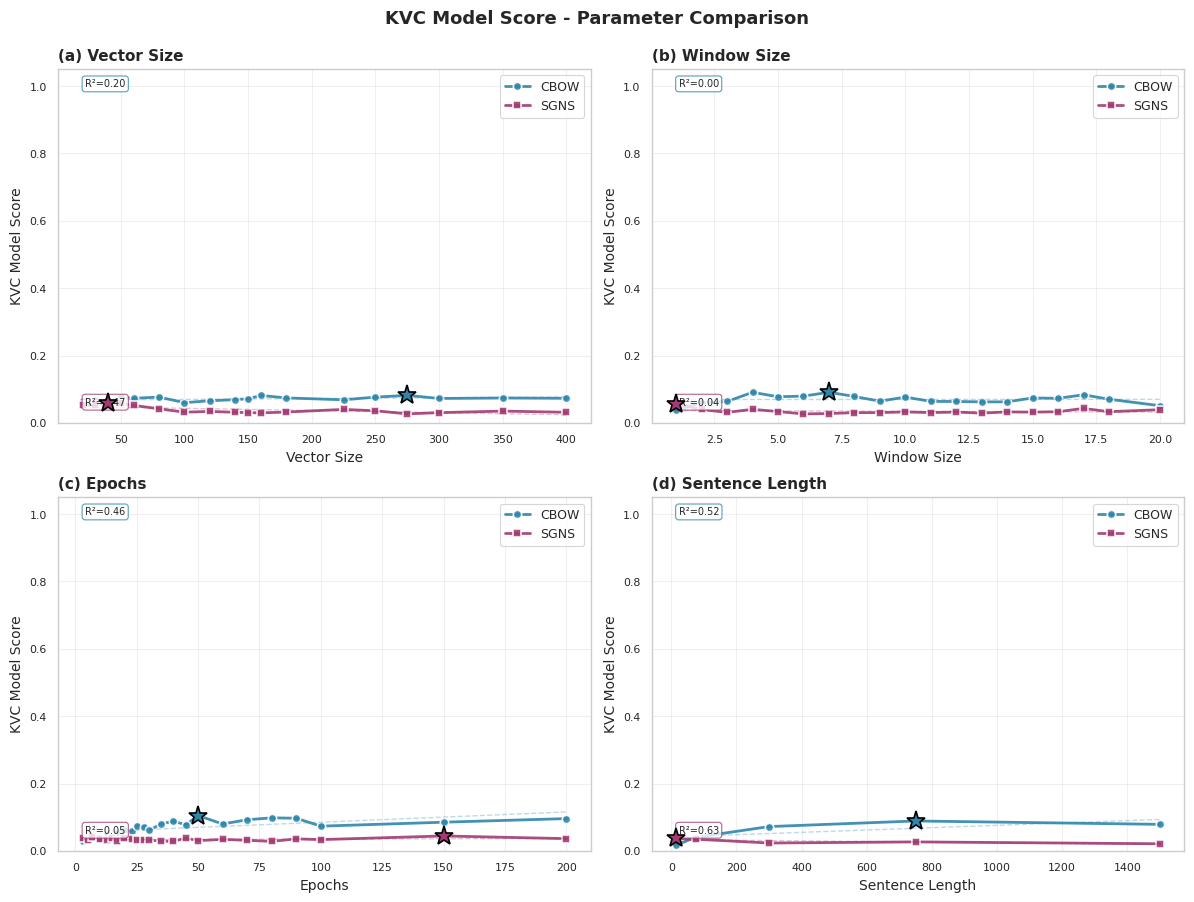


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



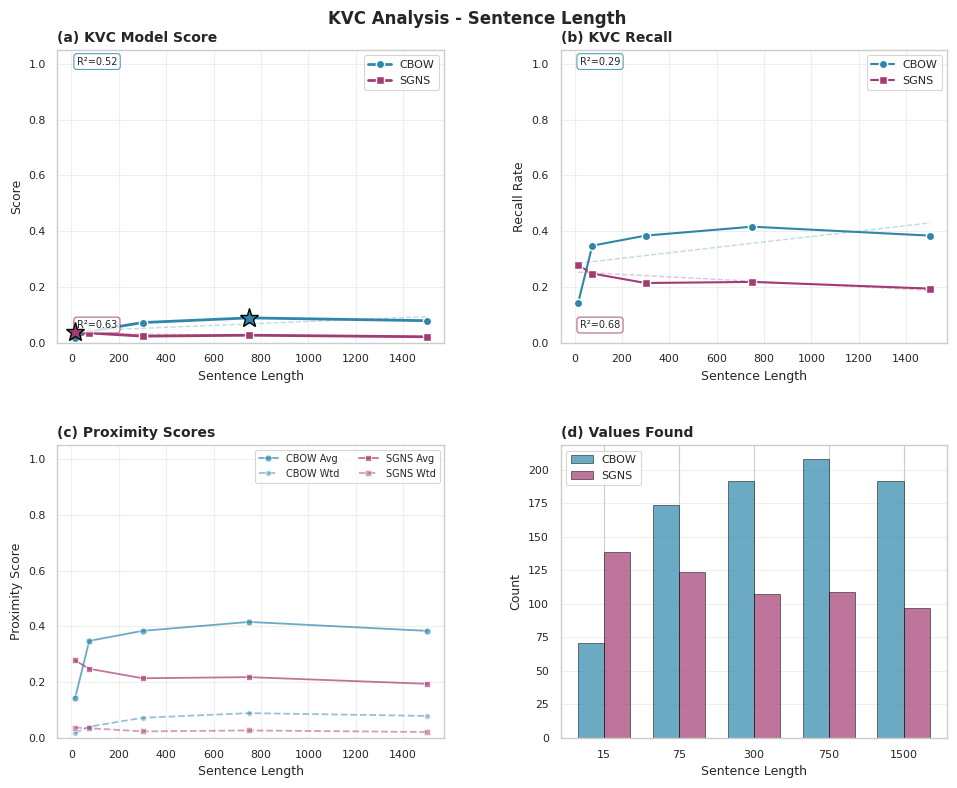

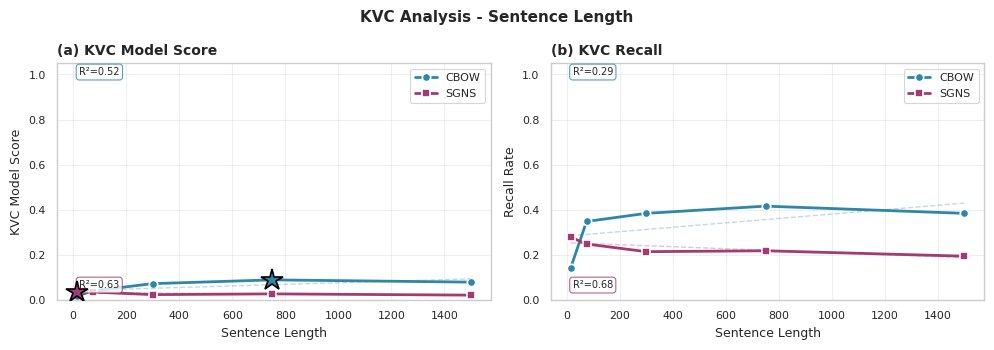

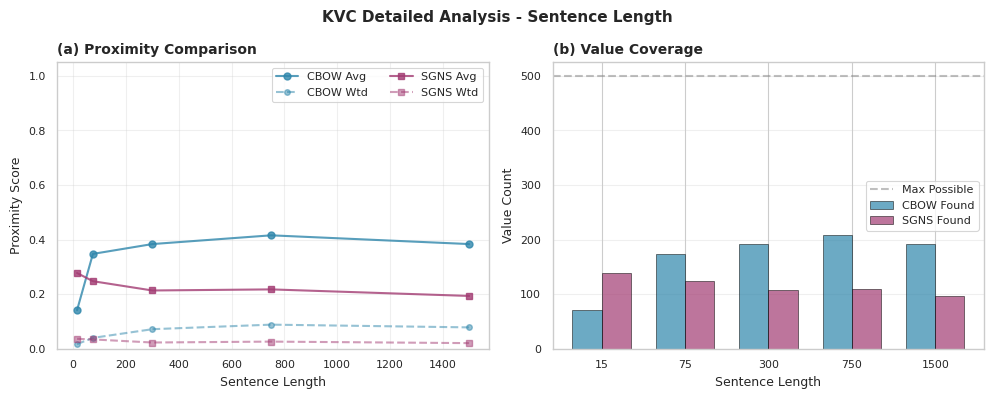


KVC NUMERICAL RESULTS - SENTENCE LENGTH

Sentence Length | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
15           | 0.0174     0.1420     0.1420     0.0174     | 0.0369     0.2780     0.2780     0.0369    
75           | 0.0404     0.3480     0.3480     0.0404     | 0.0348     0.2480     0.2480     0.0348    
300          | 0.0722     0.3840     0.3840     0.0722     | 0.0235     0.2140     0.2140     0.0235    
750          | 0.0889     0.4160     0.4160     0.0889     | 0.0268     0.2180     0.2180     0.0268    
1500         | 0.0789     0.3840     0.3840     0.0789     | 0.0212     0.1940     0.1940     0.0212    

KVC VALUE

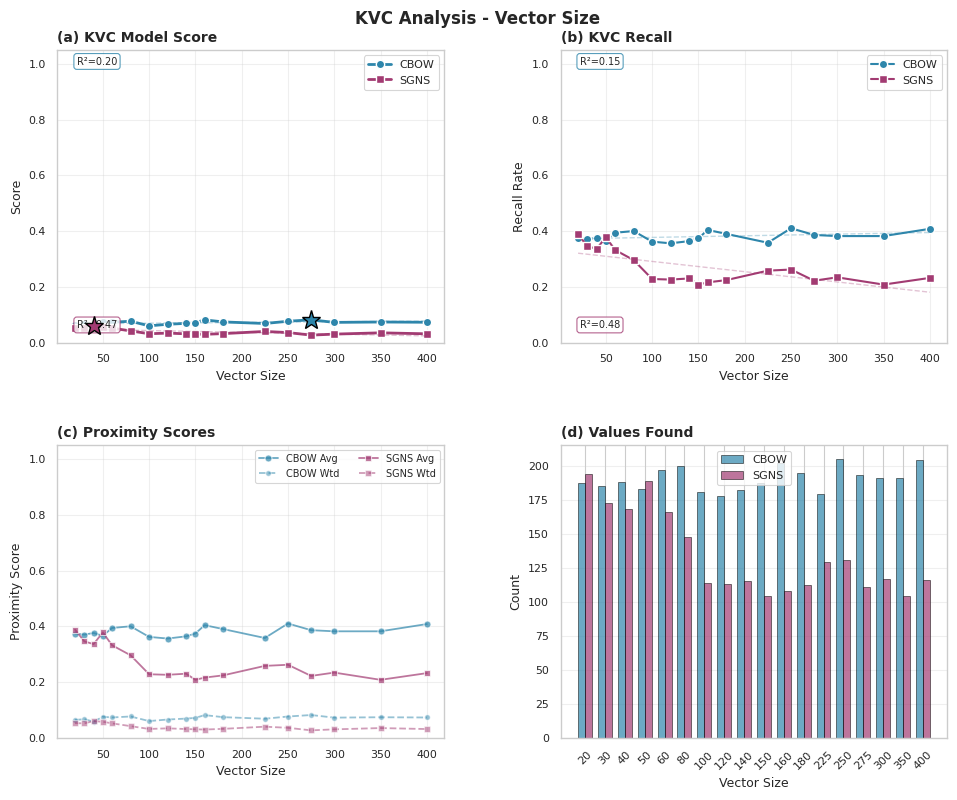

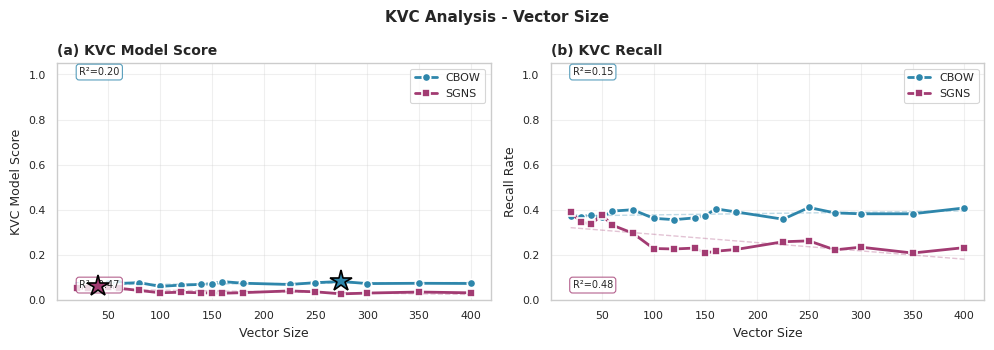

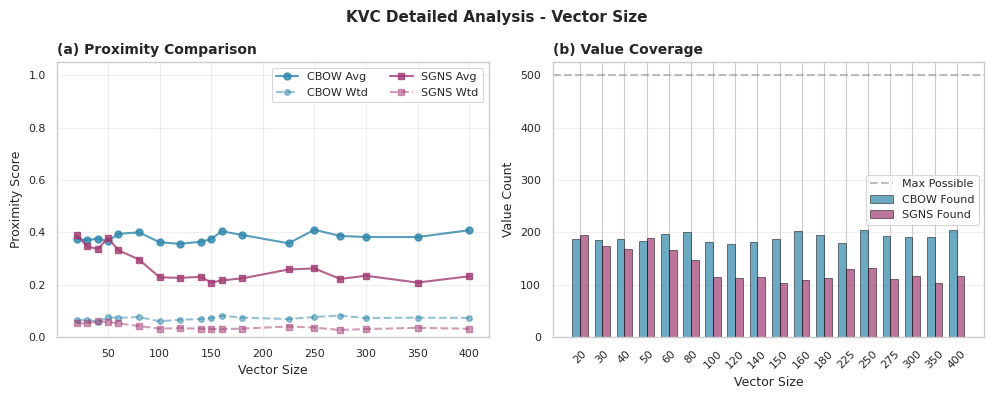


KVC NUMERICAL RESULTS - VECTOR SIZE

Vector Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
20           | 0.0641     0.3740     0.3740     0.0641     | 0.0525     0.3880     0.3880     0.0525    
30           | 0.0668     0.3700     0.3700     0.0668     | 0.0519     0.3460     0.3460     0.0519    
40           | 0.0580     0.3760     0.3760     0.0580     | 0.0599     0.3360     0.3360     0.0599    
50           | 0.0755     0.3660     0.3660     0.0755     | 0.0576     0.3780     0.3780     0.0576    
60           | 0.0730     0.3940     0.3940     0.0730     | 0.0519     0.3320     0.3320     0.0519    
80           | 0.

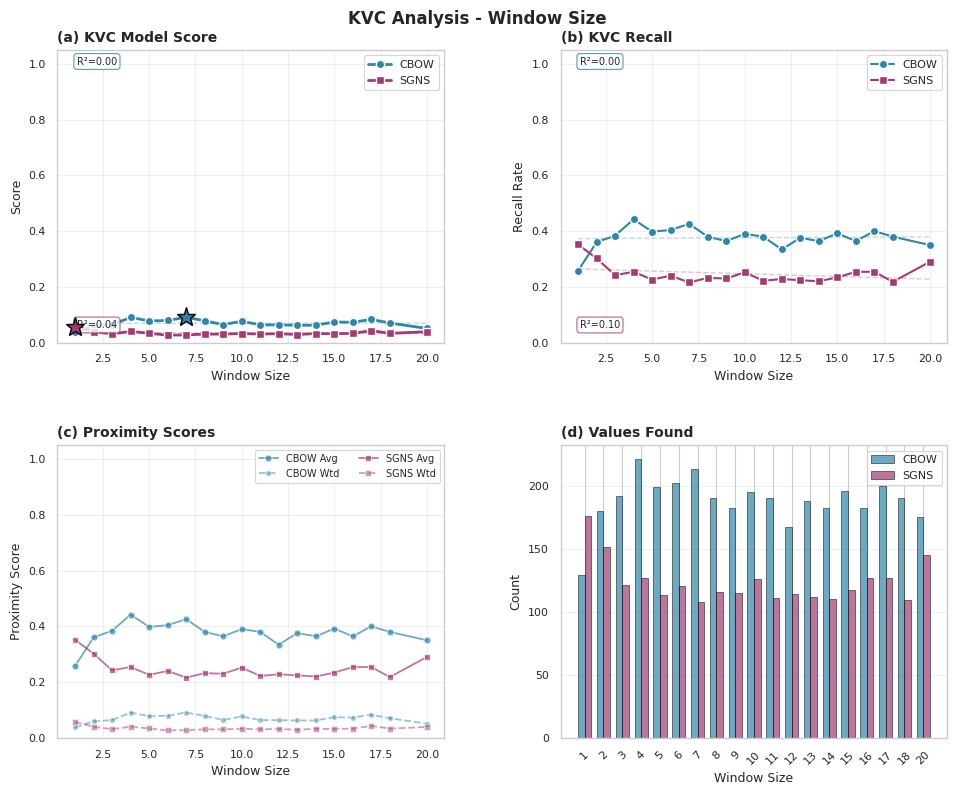

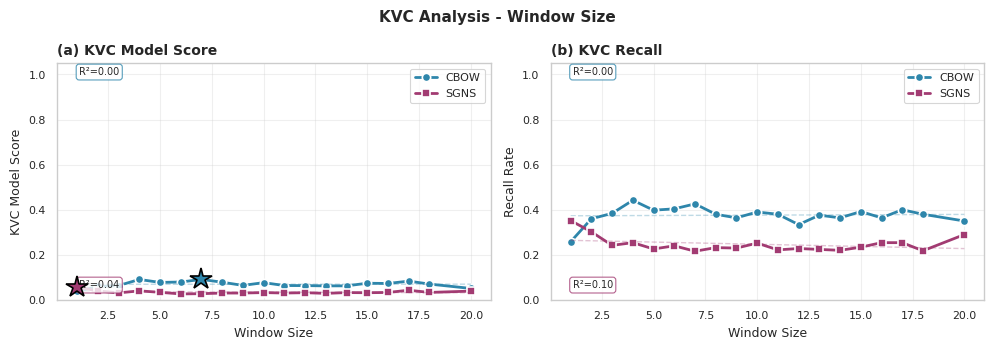

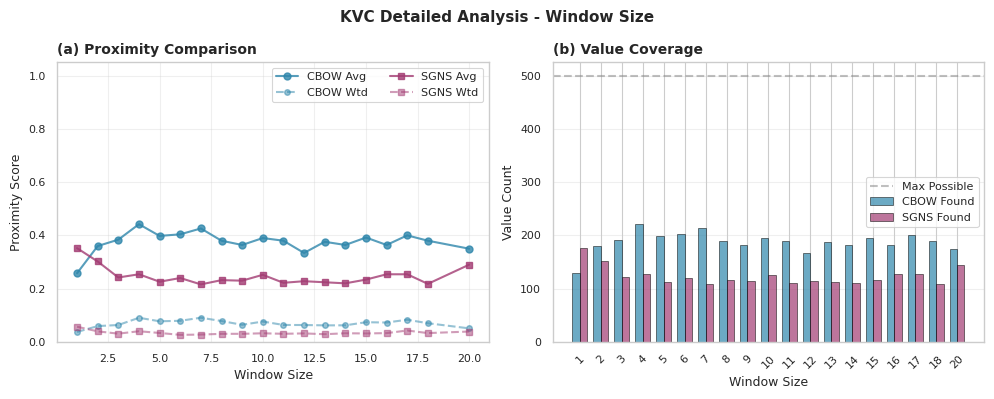


KVC NUMERICAL RESULTS - WINDOW SIZE

Window Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
1            | 0.0374     0.2580     0.2580     0.0374     | 0.0571     0.3520     0.3520     0.0571    
2            | 0.0595     0.3600     0.3600     0.0595     | 0.0397     0.3020     0.3020     0.0397    
3            | 0.0636     0.3840     0.3840     0.0636     | 0.0311     0.2420     0.2420     0.0311    
4            | 0.0908     0.4420     0.4420     0.0908     | 0.0402     0.2540     0.2540     0.0402    
5            | 0.0776     0.3980     0.3980     0.0776     | 0.0337     0.2260     0.2260     0.0337    
6            | 0.

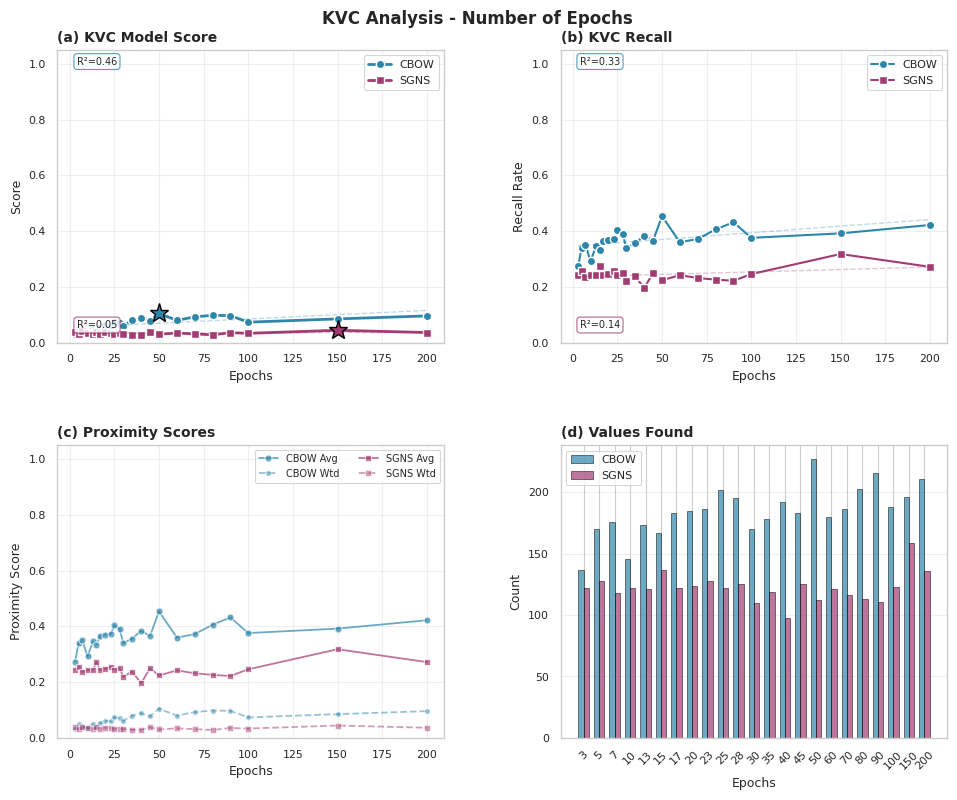

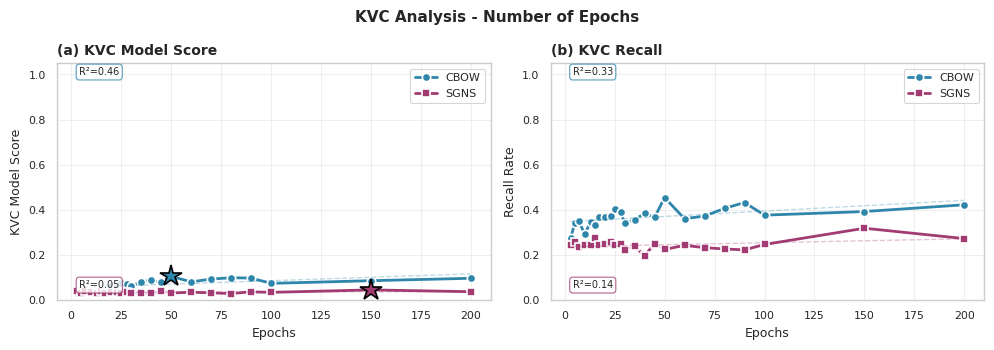

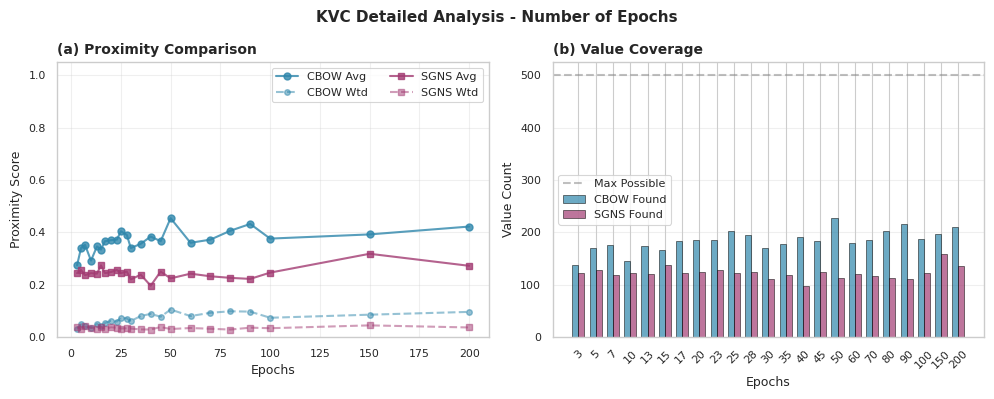


KVC NUMERICAL RESULTS - NUMBER OF EPOCHS

Epochs       | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
3            | 0.0303     0.2740     0.2740     0.0303     | 0.0378     0.2440     0.2440     0.0378    
5            | 0.0491     0.3400     0.3400     0.0491     | 0.0310     0.2560     0.2560     0.0310    
7            | 0.0405     0.3520     0.3520     0.0405     | 0.0403     0.2360     0.2360     0.0403    
10           | 0.0343     0.2920     0.2920     0.0343     | 0.0361     0.2440     0.2440     0.0361    
13           | 0.0501     0.3460     0.3460     0.0501     | 0.0313     0.2420     0.2420     0.0313    
15          

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress

# Wissenschaftliches Farbschema (konsistent mit script_2)
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'KVC_MODEL': '#F18F01',
    'KVC_RECALL': '#6A994E',
    'KVC_AVG': '#8B8C89',
    'KVC_WEIGHTED': '#BC4B51'
}

LINEWIDTHS = {
    'primary': 2.0,
    'secondary': 1.5,
    'tertiary': 1.0
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.9)


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.0)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R²={r_value**2:.2f}',
                transform=ax.transAxes, fontsize=7,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


# ============================================================================
# OPTION 1: KOMPAKTE 2x2 GRID LAYOUT (stark empfohlen)
# ============================================================================
def plot_kvc_compact_grid(category, category_data, x_label, title_category):
    """
    Kombiniert alle KVC-Hauptmetriken in einem 2x2 Grid
    Spart ~70% Platz verglichen mit 3 separaten Figuren
    """
    fig = plt.figure(figsize=(10, 8))
    
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3,
                          top=0.93, bottom=0.07, left=0.08, right=0.97)
    
    # Oben links: KVC Model Score
    ax_model = fig.add_subplot(gs[0, 0])
    
    # Oben rechts: KVC Recall
    ax_recall = fig.add_subplot(gs[0, 1])
    
    # Unten links: Proximity Scores
    ax_proximity = fig.add_subplot(gs[1, 0])
    
    # Unten rechts: Values Found
    ax_values = fig.add_subplot(gs[1, 1])
    
    fig.suptitle(f'KVC Analysis - {title_category}', fontsize=12, fontweight='bold')
    
    # ---- Panel A: KVC Model Score ----
    ax_model.set_title('(a) KVC Model Score', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_model_score']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax_model.plot(x, y, f'-{marker}', color=color, linewidth=LINEWIDTHS['primary'],
                         markersize=6, label=algorithm, markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x, y, ax_model, color, 'top' if algorithm == 'CBOW' else 'bottom')
            
            max_idx = np.argmax(y)
            ax_model.plot(x[max_idx], y[max_idx], '*', color=color, markersize=14,
                         markeredgecolor='black', markeredgewidth=1, zorder=5)
    
    ax_model.set_xlabel(x_label, fontsize=9)
    ax_model.set_ylabel('Score', fontsize=9)
    ax_model.legend(fontsize=8, frameon=True, loc='best')
    ax_model.grid(True, alpha=0.3)
    ax_model.set_ylim([0, 1.05])
    
    # ---- Panel B: KVC Recall ----
    ax_recall.set_title('(b) KVC Recall', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_recall']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax_recall.plot(x, y, f'-{marker}', color=color, linewidth=LINEWIDTHS['secondary'],
                          markersize=6, label=algorithm, markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x, y, ax_recall, color, 'top' if algorithm == 'CBOW' else 'bottom')
    
    ax_recall.set_xlabel(x_label, fontsize=9)
    ax_recall.set_ylabel('Recall Rate', fontsize=9)
    ax_recall.legend(fontsize=8, frameon=True, loc='best')
    ax_recall.grid(True, alpha=0.3)
    ax_recall.set_ylim([0, 1.05])
    
    # ---- Panel C: Proximity Scores (beide in einem Plot) ----
    ax_proximity.set_title('(c) Proximity Scores', fontsize=10, loc='left', fontweight='bold')
    
    # Beide Algorithmen, beide Proximity-Metriken
    for algorithm, marker, algo_color in [('CBOW', 'o', COLORS['CBOW']),
                                           ('SGNS', 's', COLORS['SGNS'])]:
        # Average Proximity (durchgezogen)
        avg_data = category_data[algorithm]['kvc_avg_proximity']
        if avg_data:
            x = sorted(avg_data.keys())
            y = [avg_data[xi] for xi in x]
            ax_proximity.plot(x, y, f'-{marker}', color=algo_color, linewidth=1.3,
                            markersize=5, label=f'{algorithm} Avg', alpha=0.7,
                            markeredgecolor='white', markeredgewidth=0.8)
        
        # Weighted Proximity (gestrichelt)
        wtd_data = category_data[algorithm]['kvc_weighted_proximity']
        if wtd_data:
            x = sorted(wtd_data.keys())
            y = [wtd_data[xi] for xi in x]
            ax_proximity.plot(x, y, f'--{marker}', color=algo_color, linewidth=1.3,
                            markersize=4, label=f'{algorithm} Wtd', alpha=0.5,
                            markeredgecolor='white', markeredgewidth=0.8)
    
    ax_proximity.set_xlabel(x_label, fontsize=9)
    ax_proximity.set_ylabel('Proximity Score', fontsize=9)
    ax_proximity.legend(fontsize=7, frameon=True, loc='best', ncol=2)
    ax_proximity.grid(True, alpha=0.3)
    ax_proximity.set_ylim([0, 1.05])
    
    # ---- Panel D: Values Found (Bar Chart) ----
    ax_values.set_title('(d) Values Found', fontsize=10, loc='left', fontweight='bold')
    
    x_vals = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) +
                        list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_vals:
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_vals]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_vals]
        
        x_pos = np.arange(len(x_vals))
        width = 0.35
        
        ax_values.bar(x_pos - width/2, cbow_found, width, label='CBOW',
                     color=COLORS['CBOW'], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax_values.bar(x_pos + width/2, sgns_found, width, label='SGNS',
                     color=COLORS['SGNS'], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax_values.set_xlabel(x_label, fontsize=9)
        ax_values.set_ylabel('Count', fontsize=9)
        ax_values.set_xticks(x_pos)
        ax_values.set_xticklabels(x_vals, rotation=45 if len(x_vals) > 5 else 0, fontsize=8)
        ax_values.legend(fontsize=8, frameon=True, loc='best')
        ax_values.grid(True, alpha=0.3, axis='y')
    
    return fig


# ============================================================================
# OPTION 2: HORIZONTALES LAYOUT (1 Zeile, 4 Spalten)
# ============================================================================
def plot_kvc_horizontal_layout(category, category_data, x_label, title_category):
    """
    Alle KVC-Metriken in einer Zeile
    Ideal für zweispaltige LaTeX-Dokumente (nutzt volle Textbreite)
    """
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(f'KVC Analysis - {title_category}', fontsize=11, fontweight='bold', y=0.98)
    
    ax_model, ax_recall, ax_prox, ax_vals = axes
    
    # Panel A: Model Score
    ax_model.set_title('(a) Model', fontsize=9, fontweight='bold')
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_model_score']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax_model.plot(x, y, f'-{marker}', color=color, linewidth=1.6,
                         markersize=5, label=algorithm, markeredgecolor='white', markeredgewidth=0.8)
    
    ax_model.set_xlabel(x_label, fontsize=8)
    ax_model.set_ylabel('Score', fontsize=8)
    ax_model.legend(fontsize=7, frameon=True)
    ax_model.grid(True, alpha=0.3)
    ax_model.set_ylim([0, 1.05])
    
    # Panel B: Recall
    ax_recall.set_title('(b) Recall', fontsize=9, fontweight='bold')
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_recall']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax_recall.plot(x, y, f'-{marker}', color=color, linewidth=1.6,
                          markersize=5, label=algorithm, markeredgecolor='white', markeredgewidth=0.8)
    
    ax_recall.set_xlabel(x_label, fontsize=8)
    ax_recall.set_ylabel('Recall', fontsize=8)
    ax_recall.legend(fontsize=7, frameon=True)
    ax_recall.grid(True, alpha=0.3)
    ax_recall.set_ylim([0, 1.05])
    
    # Panel C: Proximity (kompakt)
    ax_prox.set_title('(c) Proximity', fontsize=9, fontweight='bold')
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        avg_data = category_data[algorithm]['kvc_avg_proximity']
        if avg_data:
            x = sorted(avg_data.keys())
            y = [avg_data[xi] for xi in x]
            ax_prox.plot(x, y, f'-{marker}', color=color, linewidth=1.3,
                        markersize=4, label=algorithm, alpha=0.7,
                        markeredgecolor='white', markeredgewidth=0.8)
    
    ax_prox.set_xlabel(x_label, fontsize=8)
    ax_prox.set_ylabel('Avg Prox', fontsize=8)
    ax_prox.legend(fontsize=7, frameon=True)
    ax_prox.grid(True, alpha=0.3)
    ax_prox.set_ylim([0, 1.05])
    
    # Panel D: Values
    ax_vals.set_title('(d) Values', fontsize=9, fontweight='bold')
    x_vals = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) +
                        list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_vals and len(x_vals) <= 6:  # Nur wenn nicht zu viele Werte
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_vals]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_vals]
        
        x_pos = np.arange(len(x_vals))
        width = 0.35
        
        ax_vals.bar(x_pos - width/2, cbow_found, width, label='CBOW',
                   color=COLORS['CBOW'], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax_vals.bar(x_pos + width/2, sgns_found, width, label='SGNS',
                   color=COLORS['SGNS'], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax_vals.set_xticks(x_pos)
        ax_vals.set_xticklabels(x_vals, fontsize=7)
    
    ax_vals.set_xlabel(x_label, fontsize=8)
    ax_vals.set_ylabel('Count', fontsize=8)
    ax_vals.legend(fontsize=7, frameon=True)
    ax_vals.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig


# ============================================================================
# OPTION 3: ULTRA-KOMPAKT (nur Model Score + Recall)
# ============================================================================
def plot_kvc_essential_only(category, category_data, x_label, title_category):
    """
    Nur die wichtigsten KVC-Metriken (Model Score + Recall)
    Proximity & Values → Supplementary Material
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.suptitle(f'KVC Analysis - {title_category}', fontsize=11, fontweight='bold', y=0.98)
    
    # Panel A: Model Score
    ax1.set_title('(a) KVC Model Score', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_model_score']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, f'-{marker}', color=color, linewidth=2.0,
                    markersize=6, label=algorithm, markeredgecolor='white', markeredgewidth=1.2)
            add_trend_analysis(x, y, ax1, color, 'top' if algorithm == 'CBOW' else 'bottom')
            
            max_idx = np.argmax(y)
            ax1.plot(x[max_idx], y[max_idx], '*', color=color, markersize=16,
                    markeredgecolor='black', markeredgewidth=1.2, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=9)
    ax1.set_ylabel('KVC Model Score', fontsize=9)
    ax1.legend(fontsize=8, frameon=True, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Recall
    ax2.set_title('(b) KVC Recall', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        data = category_data[algorithm]['kvc_recall']
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, f'-{marker}', color=color, linewidth=2.0,
                    markersize=6, label=algorithm, markeredgecolor='white', markeredgewidth=1.2)
            add_trend_analysis(x, y, ax2, color, 'top' if algorithm == 'CBOW' else 'bottom')
    
    ax2.set_xlabel(x_label, fontsize=9)
    ax2.set_ylabel('Recall Rate', fontsize=9)
    ax2.legend(fontsize=8, frameon=True, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig


# ============================================================================
# OPTION 4: SUPPLEMENTARY - Detaillierte Komponenten
# ============================================================================
def plot_kvc_supplementary(category, category_data, x_label, title_category):
    """
    Detaillierte Proximity-Analyse für Supplementary Material
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'KVC Detailed Analysis - {title_category}', fontsize=11, fontweight='bold')
    
    # Panel A: Average vs Weighted Proximity
    ax1.set_title('(a) Proximity Comparison', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                      ('SGNS', 's', COLORS['SGNS'])]:
        avg_data = category_data[algorithm]['kvc_avg_proximity']
        wtd_data = category_data[algorithm]['kvc_weighted_proximity']
        
        if avg_data:
            x = sorted(avg_data.keys())
            y = [avg_data[xi] for xi in x]
            ax1.plot(x, y, f'-{marker}', color=color, linewidth=1.5,
                    markersize=5, label=f'{algorithm} Avg', alpha=0.8)
        
        if wtd_data:
            x = sorted(wtd_data.keys())
            y = [wtd_data[xi] for xi in x]
            ax1.plot(x, y, f'--{marker}', color=color, linewidth=1.5,
                    markersize=4, label=f'{algorithm} Wtd', alpha=0.5)
    
    ax1.set_xlabel(x_label, fontsize=9)
    ax1.set_ylabel('Proximity Score', fontsize=9)
    ax1.legend(fontsize=8, frameon=True, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Values Found vs Possible
    ax2.set_title('(b) Value Coverage', fontsize=10, loc='left', fontweight='bold')
    
    x_vals = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) +
                        list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_vals:
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_vals]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_vals]
        cbow_possible = [category_data['CBOW']['kvc_possible_values'].get(x, 0) for x in x_vals]
        
        x_pos = np.arange(len(x_vals))
        width = 0.35
        
        ax2.bar(x_pos - width/2, cbow_found, width, label='CBOW Found',
               color=COLORS['CBOW'], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax2.bar(x_pos + width/2, sgns_found, width, label='SGNS Found',
               color=COLORS['SGNS'], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        if any(cbow_possible):
            max_possible = max(cbow_possible)
            ax2.axhline(y=max_possible, color='gray', linestyle='--',
                       alpha=0.5, linewidth=1.5, label='Max Possible')
        
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(x_vals, rotation=45 if len(x_vals) > 5 else 0)
    
    ax2.set_xlabel(x_label, fontsize=9)
    ax2.set_ylabel('Value Count', fontsize=9)
    ax2.legend(fontsize=8, frameon=True)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig


# ============================================================================
# OPTION 5: ALLE KVC MODEL SCORES IN EINER FIGUR (2x2 Grid)
# ============================================================================
def plot_all_kvc_model_scores(all_categories_data):
    """
    Zeigt KVC Model Scores für alle 4 wichtigsten Kategorien in einem 2x2 Grid
    Perfekt für kompakte Übersicht in wissenschaftlichen Arbeiten
    """
    # Definiere die 4 wichtigsten Kategorien
    important_categories = {
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'sentence': ('Sentence Length', 'Sentence Length')
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle('KVC Model Score - Parameter Comparison', 
                 fontsize=13, fontweight='bold', y=0.995)
    
    axes_flat = axes.flatten()
    panel_labels = ['(a)', '(b)', '(c)', '(d)']
    
    for idx, (category, (x_label, title)) in enumerate(important_categories.items()):
        if idx >= 4:
            break
            
        ax = axes_flat[idx]
        
        if category not in all_categories_data:
            ax.text(0.5, 0.5, f'No data for {title}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{panel_labels[idx]} {title}', fontsize=11, 
                        loc='left', fontweight='bold')
            continue
        
        category_data = all_categories_data[category]
        
        # Plot beide Algorithmen
        has_data = False
        for algorithm, marker, color in [('CBOW', 'o', COLORS['CBOW']),
                                          ('SGNS', 's', COLORS['SGNS'])]:
            data = category_data[algorithm]['kvc_model_score']
            if data:
                x = sorted(data.keys())
                y = [data[xi] for xi in x]
                ax.plot(x, y, f'-{marker}', color=color, linewidth=2.0,
                       markersize=6, label=algorithm, markeredgecolor='white', 
                       markeredgewidth=1.2, alpha=0.9)
                add_trend_analysis(x, y, ax, color, 
                                 'top' if algorithm == 'CBOW' else 'bottom')
                
                # Markiere Maximum
                max_idx = np.argmax(y)
                ax.plot(x[max_idx], y[max_idx], '*', color=color, markersize=14,
                       markeredgecolor='black', markeredgewidth=1.2, zorder=5)
                has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel('KVC Model Score', fontsize=10)
            ax.set_title(f'{panel_labels[idx]} {title}', fontsize=11, 
                        loc='left', fontweight='bold')
            ax.legend(fontsize=9, frameon=True, loc='best')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
        else:
            ax.text(0.5, 0.5, f'No KVC data for {title}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{panel_labels[idx]} {title}', fontsize=11, 
                        loc='left', fontweight='bold')
    
    plt.tight_layout()
    return fig


# ============================================================================
# HAUPTSCHLEIFE - AKTUALISIERT
# ============================================================================

print("\n" + "="*100)
print("KEY-VALUE COHERENCE (KVC) ANALYSIS - COMPACT VISUALIZATION")
print("="*100 + "\n")

# OPTION 5: Erst alle Model Scores zusammen ausgeben
print("\n" + "#"*100)
print("# CREATING COMBINED KVC MODEL SCORE OVERVIEW")
print("#"*100 + "\n")

fig_all_model_scores = plot_all_kvc_model_scores(data_by_category)
render_figure(fig_all_model_scores, "KVC_all_model_scores_combined")

# Dann einzelne Kategorien
for category, category_data in data_by_category.items():
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    # Prüfe ob KVC-Daten vorhanden sind
    has_kvc_data = False
    for algorithm in ['CBOW', 'SGNS']:
        if category_data[algorithm]['kvc_model_score']:
            has_kvc_data = True
            break
    
    if not has_kvc_data:
        print(f"  No KVC data available for category: {title_category}")
        continue
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # OPTION 1: Kompaktes 2x2 Grid (EMPFOHLEN für Haupttext)
    fig_compact = plot_kvc_compact_grid(category, category_data, x_label, title_category)
    render_figure(fig_compact, f"KVC_compact_grid_{category}")
    
    # OPTION 2: Horizontales Layout (alternativ)
    # fig_horizontal = plot_kvc_horizontal_layout(category, category_data, x_label, title_category)
    # render_figure(fig_horizontal, f"KVC_horizontal_{category}")
    
    # OPTION 3: Nur Essentials (für sehr platzbegrenzte Situationen)
    fig_essential = plot_kvc_essential_only(category, category_data, x_label, title_category)
    render_figure(fig_essential, f"KVC_essential_{category}")
    
    # OPTION 4: Supplementary Details
    fig_supplement = plot_kvc_supplementary(category, category_data, x_label, title_category)
    render_figure(fig_supplement, f"KVC_supplementary_{category}")
    
    # TABLE bleibt unverändert
    create_kvc_summary_table(category, category_data, x_label, title_category)

print("\n" + "="*100)
print("KVC ANALYSIS COMPLETE")
print("="*100)


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



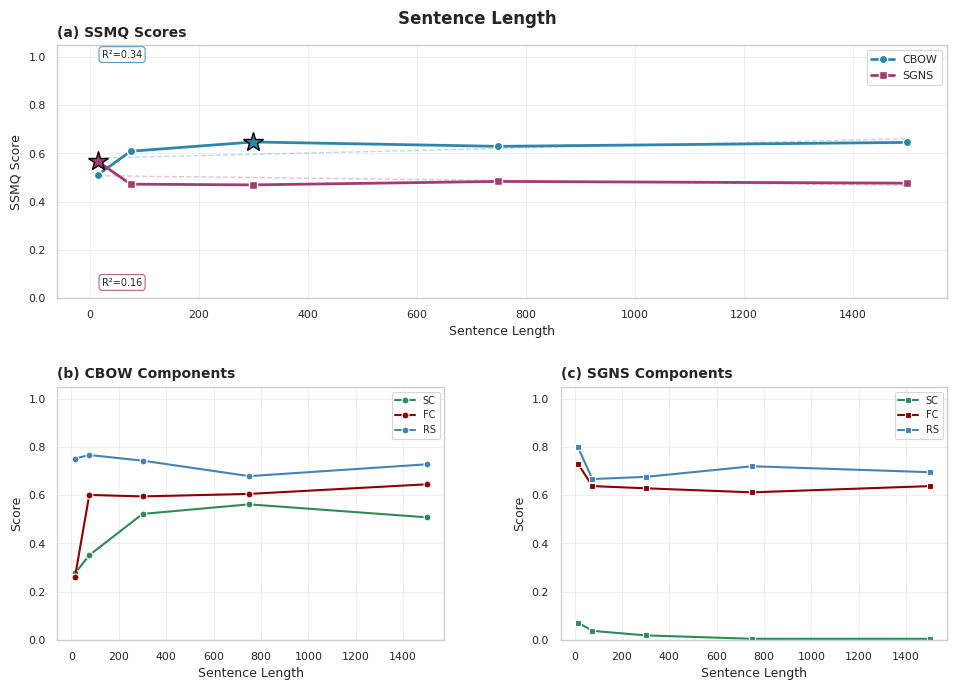


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
15           | 0.2762    0.2621    0.7521    0.5114    | 0.0717    0.7301    0.7980    0.5666   
75           | 0.3512    0.6013    0.7668    0.6090    | 0.0377    0.6380    0.6672    0.4725   
300          | 0.5225    0.5951    0.7435    0.6475    | 0.0188    0.6288    0.6762    0.4695   
750          | 0.5622    0.6055    0.6792    0.6294    | 0.0046    0.6120    0.7202    0.4839   
1500         | 0.5084    0.6454    0.7283    0.6457    | 0.0045    0.6379    0.6956    0.4767   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

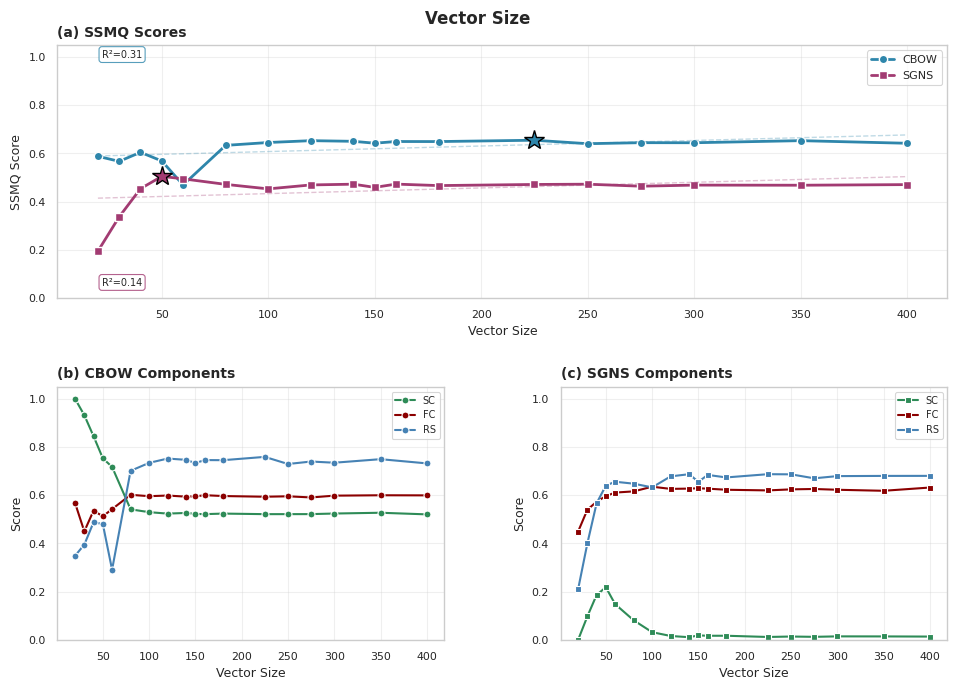


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 1.0000    0.5680    0.3489    0.5880    | 0.0000    0.4492    0.2096    0.1946   
30           | 0.9320    0.4501    0.3950    0.5671    | 0.0974    0.5398    0.3999    0.3371   
40           | 0.8447    0.5361    0.4879    0.6046    | 0.1864    0.5731    0.5667    0.4539   
50           | 0.7533    0.5125    0.4807    0.5688    | 0.2183    0.5966    0.6401    0.5048   
60           | 0.7175    0.5424    0.2913    0.4694    | 0.1484    0.6110    0.6560    0.4947   
80           | 0.5415    0.6018    0.7012    0.6334    | 0.0815    0.6160    0.6480    0.4716   
100          | 0.5298    0.5961    0.7342    0.6453    | 0.0320    0.6353    0.6326   

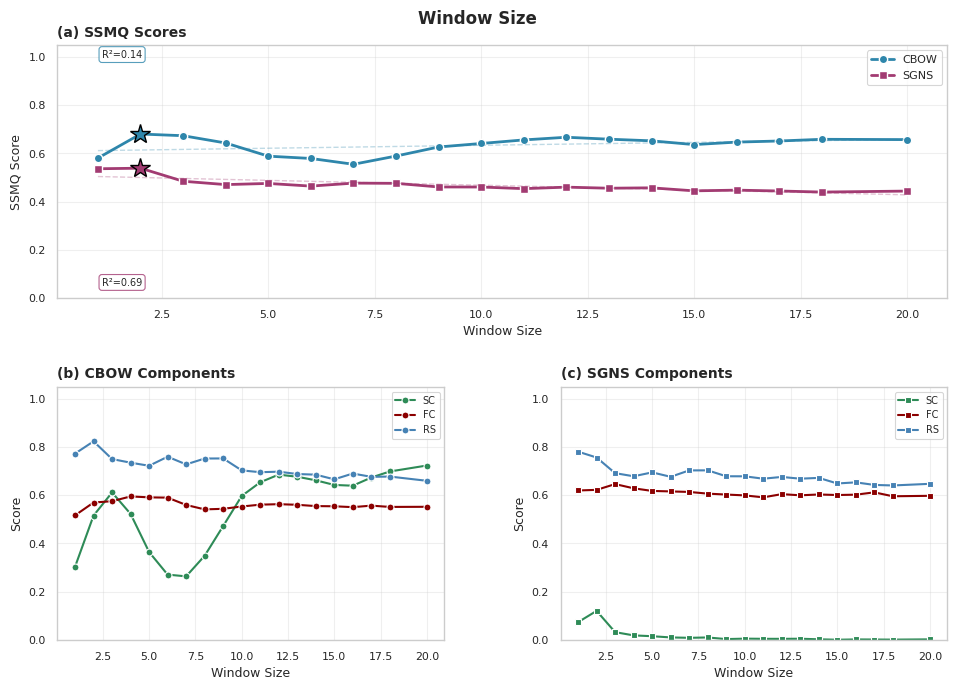


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.3033    0.5165    0.7727    0.5806    | 0.0737    0.6197    0.7807    0.5364   
2            | 0.5157    0.5698    0.8235    0.6804    | 0.1204    0.6223    0.7565    0.5388   
3            | 0.6115    0.5751    0.7500    0.6735    | 0.0321    0.6462    0.6915    0.4847   
4            | 0.5225    0.5951    0.7350    0.6433    | 0.0188    0.6288    0.6787    0.4707   
5            | 0.3645    0.5912    0.7222    0.5887    | 0.0153    0.6178    0.6948    0.4756   
6            | 0.2708    0.5900    0.7598    0.5791    | 0.0103    0.6158    0.6765    0.4645   
7            | 0.2636    0.5597    0.7279    0.5550    | 0.0087    0.6137    0.702

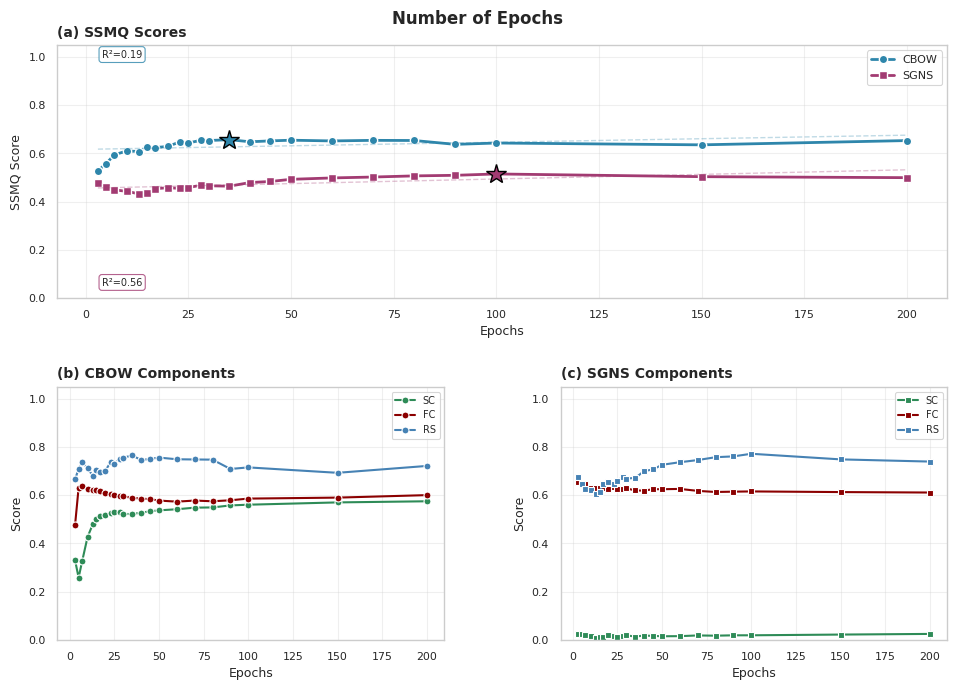


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.3307    0.4760    0.6666    0.5277    | 0.0264    0.6566    0.6747    0.4766   
5            | 0.2584    0.6310    0.7083    0.5579    | 0.0249    0.6481    0.6459    0.4600   
7            | 0.3271    0.6392    0.7367    0.5943    | 0.0211    0.6461    0.6267    0.4489   
10           | 0.4266    0.6276    0.7133    0.6102    | 0.0168    0.6319    0.6229    0.4429   
13           | 0.4809    0.6215    0.6788    0.6079    | 0.0097    0.6301    0.6070    0.4325   
15           | 0.4997    0.6211    0.7030    0.6256    | 0.0111    0.6285    0.6131    0.4356   
17           | 0.5126    0.6168    0.6948    0.6246    | 0.0132    0.6318    0.6465    

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress

# Wissenschaftliches Farbschema - UNVERÄNDERT
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'SSMQ': '#F18F01',
    'ND': '#6A994E',
    'FC': '#BC4B51',
    'RS': '#8B8C89'
}

LINEWIDTHS = {
    'primary': 2.0,
    'secondary': 1.5,
    'tertiary': 1.0
}

COMPONENT_COLORS = {
    'nd': '#2E8B57',
    'fc': '#8B0000',
    'rs_mean': '#4682B4'
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.9)  # Kleinere Schrift für kompaktere Darstellung


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.0)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R²={r_value**2:.2f}',  # Kürzeres Format
                transform=ax.transAxes, fontsize=7,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


# ============================================================================
# OPTION 1: KOMPAKTE 2x2 GRID LAYOUT (stark empfohlen für LaTeX)
# ============================================================================
def plot_compact_grid(category, category_data, x_label, title_category):
    """
    Kombiniert SSMQ und Komponenten in einem 2x2 Grid
    Spart ~60% Platz verglichen mit separaten Figuren
    """
    fig = plt.figure(figsize=(10, 7))  # Kompakte Gesamtgröße
    
    # GridSpec für flexibles Layout
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3, 
                          top=0.93, bottom=0.08, left=0.08, right=0.97)
    
    # Oben: SSMQ für beide Algorithmen (größerer Plot)
    ax_ssmq = fig.add_subplot(gs[0, :])
    
    # Unten links: CBOW Komponenten
    ax_cbow = fig.add_subplot(gs[1, 0])
    
    # Unten rechts: SGNS Komponenten
    ax_sgns = fig.add_subplot(gs[1, 1])
    
    # Gesamt-Titel
    fig.suptitle(f'{title_category}', fontsize=12, fontweight='bold')
    
    # ---- SSMQ Plot (oben, volle Breite) ----
    ax_ssmq.set_title('(a) SSMQ Scores', fontsize=10, loc='left', fontweight='bold')
    
    for algorithm, marker, algo_color in [('CBOW', 'o', COLORS['CBOW']), 
                                           ('SGNS', 's', COLORS['SGNS'])]:
        ssmq_data = category_data[algorithm]['ssmq']
        if ssmq_data:
            x = sorted(ssmq_data.keys())
            y = [ssmq_data[xi] for xi in x]
            ax_ssmq.plot(x, y, f'-{marker}', color=algo_color, 
                        linewidth=LINEWIDTHS['primary'], markersize=6,
                        label=algorithm, markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x, y, ax_ssmq, algo_color, 
                             'top' if algorithm == 'CBOW' else 'bottom')
            
            max_idx = np.argmax(y)
            ax_ssmq.plot(x[max_idx], y[max_idx], '*', color=algo_color, 
                        markersize=15, markeredgecolor='black', 
                        markeredgewidth=1, zorder=5)
    
    ax_ssmq.set_xlabel(x_label, fontsize=9)
    ax_ssmq.set_ylabel('SSMQ Score', fontsize=9)
    ax_ssmq.legend(fontsize=8, frameon=True, loc='best')
    ax_ssmq.grid(True, alpha=0.3)
    ax_ssmq.set_ylim([0, 1.05])
    
    # ---- Komponenten-Plots ----
    components = [
        ('nd', 'SC', COMPONENT_COLORS['nd']),
        ('fc', 'FC', COMPONENT_COLORS['fc']),
        ('rs_mean', 'RS', COMPONENT_COLORS['rs_mean'])
    ]
    
    for ax, algorithm, marker, title_letter in [(ax_cbow, 'CBOW', 'o', 'b'), 
                                                  (ax_sgns, 'SGNS', 's', 'c')]:
        ax.set_title(f'({title_letter}) {algorithm} Components', fontsize=10, 
                    loc='left', fontweight='bold')
        
        for metric_key, metric_label, color in components:
            data = category_data[algorithm][metric_key]
            if data:
                x = sorted(data.keys())
                y = [data[xi] for xi in x]
                ax.plot(x, y, f'-{marker}', color=color, 
                       linewidth=LINEWIDTHS['secondary'], markersize=5,
                       label=metric_label, markeredgecolor='white', markeredgewidth=0.8)
        
        ax.set_xlabel(x_label, fontsize=9)
        ax.set_ylabel('Score', fontsize=9)
        ax.legend(fontsize=7, frameon=True, loc='best', ncol=1)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])
    
    return fig


# ============================================================================
# OPTION 2: HORIZONTALES LAYOUT (1 Zeile, 3 Spalten)
# ============================================================================
def plot_horizontal_layout(category, category_data, x_label, title_category):
    """
    Alle Plots in einer Zeile - ideal für zweispaltige LaTeX-Dokumente
    Figur nimmt volle Textbreite ein, aber wenig Höhe
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    fig.suptitle(f'{title_category}', fontsize=11, fontweight='bold', y=0.98)
    
    ax_ssmq, ax_cbow, ax_sgns = axes
    
    # SSMQ Plot
    ax_ssmq.set_title('(a) SSMQ', fontsize=9, fontweight='bold')
    for algorithm, marker, algo_color in [('CBOW', 'o', COLORS['CBOW']), 
                                           ('SGNS', 's', COLORS['SGNS'])]:
        ssmq_data = category_data[algorithm]['ssmq']
        if ssmq_data:
            x = sorted(ssmq_data.keys())
            y = [ssmq_data[xi] for xi in x]
            ax_ssmq.plot(x, y, f'-{marker}', color=algo_color, 
                        linewidth=1.8, markersize=5, label=algorithm,
                        markeredgecolor='white', markeredgewidth=1)
    
    ax_ssmq.set_xlabel(x_label, fontsize=8)
    ax_ssmq.set_ylabel('Score', fontsize=8)
    ax_ssmq.legend(fontsize=7, frameon=True)
    ax_ssmq.grid(True, alpha=0.3)
    ax_ssmq.set_ylim([0, 1.05])
    
    # Komponenten-Plots
    components = [
        ('nd', 'SC', COMPONENT_COLORS['nd']),
        ('fc', 'FC', COMPONENT_COLORS['fc']),
        ('rs_mean', 'RS', COMPONENT_COLORS['rs_mean'])
    ]
    
    for ax, algorithm, marker, title_letter in [(ax_cbow, 'CBOW', 'o', 'b'),
                                                  (ax_sgns, 'SGNS', 's', 'c')]:
        ax.set_title(f'({title_letter}) {algorithm}', fontsize=9, fontweight='bold')
        for metric_key, metric_label, color in components:
            data = category_data[algorithm][metric_key]
            if data:
                x = sorted(data.keys())
                y = [data[xi] for xi in x]
                ax.plot(x, y, f'-{marker}', color=color, linewidth=1.5,
                       markersize=4, label=metric_label, 
                       markeredgecolor='white', markeredgewidth=0.8)
        
        ax.set_xlabel(x_label, fontsize=8)
        ax.set_ylabel('Score', fontsize=8)
        ax.legend(fontsize=6, frameon=True, ncol=1)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig


# ============================================================================
# OPTION 3: ULTRA-KOMPAKT (nur SSMQ, Komponenten in Supplementary)
# ============================================================================
def plot_ssmq_only(category, category_data, x_label, title_category):
    """
    Nur SSMQ - für Haupttext
    Komponenten-Details in separater Supplementary-Figur
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))
    fig.suptitle(f'{title_category} - SSMQ', fontsize=10, fontweight='bold', y=0.96)
    
    for algorithm, marker, algo_color in [('CBOW', 'o', COLORS['CBOW']), 
                                           ('SGNS', 's', COLORS['SGNS'])]:
        ssmq_data = category_data[algorithm]['ssmq']
        if ssmq_data:
            x = sorted(ssmq_data.keys())
            y = [ssmq_data[xi] for xi in x]
            ax.plot(x, y, f'-{marker}', color=algo_color, 
                   linewidth=2.0, markersize=6, label=algorithm,
                   markeredgecolor='white', markeredgewidth=1.2)
            add_trend_analysis(x, y, ax, algo_color,
                             'top' if algorithm == 'CBOW' else 'bottom')
            
            max_idx = np.argmax(y)
            ax.plot(x[max_idx], y[max_idx], '*', color=algo_color,
                   markersize=16, markeredgecolor='black', 
                   markeredgewidth=1.2, zorder=5)
    
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel('SSMQ Score', fontsize=9)
    ax.legend(fontsize=8, frameon=True, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig


# ============================================================================
# HAUPTSCHLEIFE - AKTUALISIERT
# ============================================================================

# Beispiel-Verwendung in deiner Hauptschleife:
for category, category_data in data_by_category.items():
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # OPTION 1: Kompaktes 2x2 Grid (empfohlen)
    fig_compact = plot_compact_grid(category, category_data, x_label, title_category)
    render_figure(fig_compact, f"compact_grid_{category}")
    
    # OPTION 2: Horizontales Layout (alternativ)
    # fig_horizontal = plot_horizontal_layout(category, category_data, x_label, title_category)
    # render_figure(fig_horizontal, f"horizontal_{category}")
    
    # OPTION 3: Nur SSMQ (für sehr platzbegrenzte Situationen)
    # fig_ssmq = plot_ssmq_only(category, category_data, x_label, title_category)
    # render_figure(fig_ssmq, f"ssmq_only_{category}")
    
    # TABLE bleibt unverändert
    create_summary_table(category, category_data, x_label)

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)